# All-in vs. DCA: When Does Timing Matter?

**Author:** Kai-Lun Lin  
**Date:** 2026-03-27  

---

## How to Read This Notebook

1. Start from Executive Summary
2. Skip to Key Results if short on time
3. Check Methodology for technical details
4. Review Conclusion & Decision Framework


## TL;DR

- All-in → higher expected return
- DCA → lower downside risk
- Near market highs → DCA outperforms more frequently
- Strategy choice depends on risk tolerance and market regime

---

## Executive Summary

This project compares two common capital deployment strategies:

- **All-in (lump-sum investing)**: invest the full amount immediately
- **Dollar-Cost Averaging (DCA)**: spread purchases over time

The analysis combines three perspectives:

1. **Historical backtesting**
2. **Peak-entry scenario analysis**
3. **Monte Carlo simulation**


### Main Findings

- Over long horizons, **All-in usually delivers the higher expected return** because more capital is exposed to the market earlier.
- **DCA reduces downside risk** and is more robust when the entry point is unfavorable.
- Near local peaks or recent highs, **DCA can outperform All-in more often and with smaller drawdowns**.
- The choice between All-in and DCA is therefore not only a return question, but also a **timing-risk and risk-tolerance question**.


## 1. Research Question

Investors often face a practical decision:

- Should capital be invested immediately (**All-in**)?
- Or should it be deployed gradually over time (**DCA**)?

This project studies the trade-off between:

- **return maximization**
- **downside risk**
- **entry-timing uncertainty**

Specifically, we ask:

1. Does **All-in** outperform **DCA** over long horizons?
2. Does **DCA** become more attractive when the investor enters near market peaks?
3. Under simulated future paths, how stable are these conclusions across different assumptions?


## 2. Methodology

We evaluate All-in and DCA from four complementary angles.

### 2.1 Historical Backtesting
- Compare yearly entry points using realized market data
- Measure return, dispersion, and win rate

### 2.2 Peak Scenario Analysis
- Identify entry points near historical highs
- Examine what happens when investors enter at relatively unfavorable times

### 2.3 Long-Horizon Monte Carlo Simulation
- Simulate future paths under two models:
  - **GBM** (parametric)
  - **Bootstrap** (non-parametric)
- Compare long-run distributions of return and risk

### 2.4 Conditional Analysis Near Recent Highs
- Restrict the initial condition to near-high market states
- Evaluate whether DCA becomes more competitive under elevated timing risk

This structure separates the question into two layers:
- **What usually happens in the overall market?**
- **What happens when entry timing is especially bad?**


## 3. Data Preparation and Setup

We download **Yuanta Taiwan Top 50 ETF (0050.TW)** from Yahoo Finance for the period **2009-01-01 to 2026-03-20**.

The raw dataset includes the usual OHLCV fields. For this project, the analysis is built mainly on the **closing price series**.

### Preprocessing steps
- Keep the trade date and closing price
- Convert the date into a consistent time index
- Create year / month / day fields when needed
- Construct return series for backtesting and simulation

### Notes
- The asset choice is deliberate: 0050 is a broad Taiwan equity benchmark
- Daily prices are used throughout the analysis
- Unless otherwise stated, transaction cost and slippage are ignored


In [1]:
# ===== setup path =====
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: k:\GitDocument\GitUpload\all-in-vs-dca


In [2]:
import src
print(src.__file__)

from src.data.load_data import load_price_data
print(load_price_data)

k:\GitDocument\GitUpload\all-in-vs-dca\src\__init__.py
<function load_price_data at 0x000001F18A806A20>


In [3]:
# Data setup
# from src.data.load_data import load_price_data
from main import get_trade_df

ticker = "0050.TW"  # or 0050.TW
start = "2009-01-01"
end = "2026-03-20"

DATA_PARAMS = {
    "ticker": ticker,
    "start": start,
    "end": end,
    "refresh": False,  # 是否強制重新下載（不讀 cache）
    "trade_day_only": True  # 是否只保留交易日（True 的話會丟掉非交易日的資料列）
}

df = load_price_data(**DATA_PARAMS)
df = get_trade_df(df)

df.head(20)

Loading from cache...


,Close,is_trade_day,date,year,month,day
2009-01-02,20.467867,True,2009-01-02,2009,1,2
2009-01-05,22.784283,True,2009-01-05,2009,1,5
2009-01-06,22.771828,True,2009-01-06,2009,1,6
2009-01-07,20.056892,True,2009-01-07,2009,1,7
2009-01-08,18.780375,True,2009-01-08,2009,1,8
2009-01-09,20.063120,True,2009-01-09,2009,1,9
2009-01-12,21.289818,True,2009-01-12,2009,1,12
2009-01-13,20.337097,True,2009-01-13,2009,1,13
2009-01-14,21.650978,True,2009-01-14,2009,1,14
2009-01-15,19.303434,True,2009-01-15,2009,1,15


In [4]:
print(type(df))
print("\n")
print(df.head())
print("\n")
print(df.dtypes)
print("\n")
print(df.columns)

<class 'pandas.core.frame.DataFrame'>


                Close  is_trade_day       date  year  month  day
2009-01-02  20.467867          True 2009-01-02  2009      1    2
2009-01-05  22.784283          True 2009-01-05  2009      1    5
2009-01-06  22.771828          True 2009-01-06  2009      1    6
2009-01-07  20.056892          True 2009-01-07  2009      1    7
2009-01-08  18.780375          True 2009-01-08  2009      1    8


Close                  float64
is_trade_day              bool
date            datetime64[ns]
year                     int32
month                    int32
day                      int32
dtype: object


Index(['Close', 'is_trade_day', 'date', 'year', 'month', 'day'], dtype='object')


### Data Notes and Modeling Assumptions

- **Data source:** Yahoo Finance
- **Asset:** 0050 (Taiwan 50 ETF)
- **Frequency:** daily price data

### Baseline assumptions
- No transaction cost
- No tax
- No slippage
- Strategy comparison is based on the same starting capital and holding rules

These assumptions simplify the comparison so that the difference between strategies is driven mainly by **timing and path exposure**, rather than execution frictions.


## 4. Historical Backtest: Yearly Entry Comparison

We begin with a simple but practical benchmark:

> If an investor has idle cash at the beginning of a year, is it better to invest immediately or to phase in the investment over time?

This section compares **All-in** and **DCA** using repeated yearly starting points. The goal is to see whether the broad historical record favors one strategy in terms of:

- average return
- win rate
- downside protection

This is the most intuitive baseline because it uses realized history before moving to scenario analysis and simulation.


In [5]:
# ===== Global Config =====
from pathlib import Path
import sys


INITIAL_CAPITAL = 1_000_000

PROJECT_ROOT = Path.cwd().resolve().parent  # 若 notebook 在 /notebooks 底下
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: K:\GitDocument\GitUpload\all-in-vs-dca


In [6]:
from src.utils.paths import (
    ensure_project_dirs,
    get_figure_path,
    get_table_path,
)

ensure_project_dirs()

In [7]:
import src
print(src.__file__)

from src.data.load_data import load_price_data
print(load_price_data)

k:\GitDocument\GitUpload\all-in-vs-dca\src\__init__.py
<function load_price_data at 0x000001F18A806A20>


## 4.1 Historical Backtest Results

### What we do
We compare All-in and DCA using yearly entry points.

### Main results
- **All-in** has the higher average return.
- **All-in** also has the higher win rate.
- **DCA** produces more stable outcomes in some years.

### Interpretation
In an upward-trending market, earlier market exposure tends to be rewarded.  
That makes All-in attractive from an expected-return perspective.

However, DCA still provides value by reducing the damage from poor short-term entry timing. In other words:

- **All-in = stronger upside capture**
- **DCA = smoother entry risk**


### Backtest Design

To make yearly comparisons consistent, we filter the price data to trading days and exclude incomplete years.

For each calendar year (for example: 2009, 2010, 2011, ...), we compare the outcome of two strategies:

- **All-in** at the first trading day of the year
- **DCA** beginning at the first trading day of the year and spreading purchases across the following months

### Parameter setting
- Initial capital: **$1,000,000**
- Entry: first trading day of January
- Holding horizon: **250 trading days**
- DCA schedule: **3 installments**
- Interval between DCA purchases: **20 trading days**

This setup allows a fair comparison of how the two strategies behave over a standardized one-year horizon.


In [8]:
# Run yearly backtest
from main import run_yearly_backtest


YEARLY_PARAMS = {
    "n_splits": 3,
    "gap_days": 30,
    "base_month": 1,
    "horizon_td": 250,
    "min_trade_days": 60,
}

res, summary_df = run_yearly_backtest(df, **YEARLY_PARAMS)


In [9]:
res.columns

Index(['Year', 'Entry_Date', 'Exit_Date', 'Horizon_TradeDays', 'n_splits',
       'gap_days', 'AllIn_Return', 'AllIn_MDD', 'DCA_Return', 'DCA_MDD',
       'DCA_Beat_AllIn'],
      dtype='object')

In [10]:
print(res.tail(5))

    Year  Entry_Date   Exit_Date  Horizon_TradeDays  n_splits  gap_days  \
12  2021  2021-01-04  2021-12-30                243         3        30   
13  2022  2022-01-03  2022-12-30                246         3        30   
14  2023  2023-01-03  2023-12-29                239         3        30   
15  2024  2024-01-02  2024-12-31                242         3        30   
16  2025  2025-01-02  2025-12-31                243         3        30   

    AllIn_Return  AllIn_MDD  DCA_Return   DCA_MDD  DCA_Beat_AllIn  
12      0.198642  -0.104425    0.110430 -0.104425           False  
13     -0.217049  -0.338276   -0.193904 -0.301560            True  
14      0.268819  -0.070554    0.188229 -0.070554           False  
15      0.492500  -0.213015    0.358504 -0.213015           False  
16      0.380578  -0.274850    0.456918 -0.178281            True  


### Summary of Yearly Backtest

From **2009 to 2025**:

- DCA's win rate relative to All-in is **0.294118**, which is below 0.5
- On average, **DCA underperforms All-in** by **-0.024679**
- The **median** return of DCA is slightly higher than All-in by **0.021804**
- The **5% worst-case return** is better for DCA:
  - DCA: **-0.183302**
  - All-in: **-0.194948**

### Interpretation

These results show a clear trade-off:

- If an investor starts with available cash and the market has a long-run upward drift, **All-in is usually better for expected return**.
- But if the investor cares about **downside protection**, DCA still has a role:
  it improves the lower tail and softens bad-entry outcomes.

So the historical evidence supports the familiar conclusion:
**All-in wins on average, while DCA helps manage entry risk.**


In [11]:
print("=== Yearly (head) ===")
print("\n")
print(res.head(10))

=== Yearly (head) ===


   Year  Entry_Date   Exit_Date  Horizon_TradeDays  n_splits  gap_days  \
0  2009  2009-01-02  2009-12-31                249         3        30   
1  2010  2010-01-04  2010-12-31                250         3        30   
2  2011  2011-01-03  2011-12-30                247         3        30   
3  2012  2012-01-02  2012-12-28                248         3        30   
4  2013  2013-01-02  2013-12-31                244         3        30   
5  2014  2014-01-02  2014-12-31                248         3        30   
6  2015  2015-01-05  2015-12-31                246         3        30   
7  2016  2016-01-04  2016-12-30                244         3        30   
8  2017  2017-01-03  2017-12-29                243         3        30   
9  2018  2018-01-02  2018-12-28                245         3        30   

   AllIn_Return  AllIn_MDD  DCA_Return   DCA_MDD  DCA_Beat_AllIn  
0      0.717372  -0.180104    0.618013 -0.109375           False  
1      0.086726  -0.167875 

In [12]:
print("\n=== Summary ===")
print("\n")
print(summary_df)


=== Summary ===


   Years  n_splits  gap_days  horizon_td   WinRate  \
0     17         3        30         250  0.294118   

   Avg_Return_Diff(DCA-AllIn)  Avg_MDD_Diff(DCA-AllIn)  AllIn_Worst5%  \
0                   -0.024679                 0.021804      -0.194948   

   DCA_Worst5%  
0    -0.183302  


In [13]:
print("=== Yearly (AllIn_Return) ===")
print(res["AllIn_Return"].describe())

print('\n')
print("=== Yearly (DCA_Return) ===")
print(res["DCA_Return"].describe())

=== Yearly (AllIn_Return) ===
count    17.000000
mean      0.185401
std       0.239527
min      -0.217049
25%       0.086726
50%       0.198642
75%       0.301990
max       0.717372
Name: AllIn_Return, dtype: float64


=== Yearly (DCA_Return) ===
count    17.000000
mean      0.160722
std       0.223762
min      -0.193904
25%       0.030218
50%       0.143772
75%       0.278974
max       0.618013
Name: DCA_Return, dtype: float64


In [14]:
import numpy as np
import matplotlib.pyplot as plt


def plot_hist_nb(
    a,
    b=None,
    label_a="All-in",
    label_b="DCA",
    bins=5,
    title=None,
    xlabel="Return",
    ylabel="Frequency",
    density=False,
):
    """
    Plot one or two histograms for strategy comparison.

    Parameters
    ----------
    a, b : array-like
        Input series. b can be None for single-series plotting.
    label_a, label_b : str
        Labels for legend.
    bins : int
        Number of histogram bins.
    title, xlabel, ylabel : str
        Plot labels.
    density : bool
        Whether to normalize histogram.
    """
    a = np.asarray(a, dtype=float)
    a = a[~np.isnan(a)]

    if b is not None:
        b = np.asarray(b, dtype=float)
        b = b[~np.isnan(b)]

    plt.figure(figsize=(8, 6))
    plt.hist(a, bins=bins, alpha=0.6, label=label_a, density=density)

    if b is not None:
        plt.hist(b, bins=bins, alpha=0.6, label=label_b, density=density)

    plt.xlabel(xlabel)
    plt.ylabel("Density" if density else ylabel)
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Return Distribution: All-in vs. DCA

The figure below shows the distribution of annual returns for All-in and DCA from **2009 to 2025**.

### Key observations
- The distribution of **DCA** is slightly shifted to the left, indicating lower expected return.
- The downside region below **0% return** is meaningful for both strategies, so neither strategy eliminates loss risk.
- The **left tail** of All-in is somewhat heavier, suggesting that when All-in loses, it can lose more.

### Interpretation
This distributional view adds nuance to the average-return result:

- **All-in** tends to generate better expected performance
- **DCA** tends to reduce the severity of poor short-term outcomes

That is why the comparison should not be framed only as “which strategy has the higher mean return,” but also as “which risk profile is acceptable to the investor.”


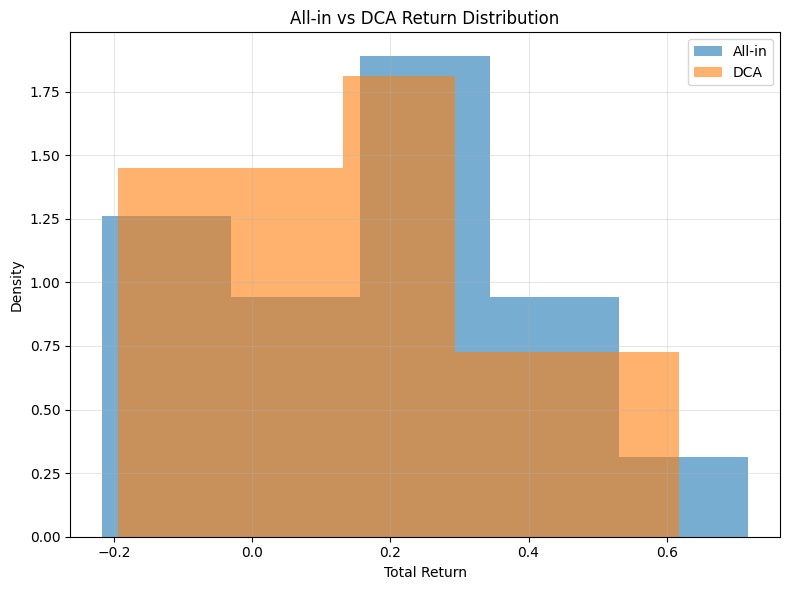

In [15]:
%matplotlib inline
plot_hist_nb(
    res["AllIn_Return"],
    res["DCA_Return"],
    label_a="All-in",
    label_b="DCA",
    bins=5,
    title="All-in vs DCA Return Distribution",
    xlabel="Total Return",
    density=True
)

## 5. Peak Entry Scenario Analysis

A common investor concern is entering the market at a **bad time**.

To study timing risk directly, this section focuses on historical episodes where price was near a local peak.

### Objective
We want to know:

> If an investor enters near a historical high, does DCA become more attractive than All-in?

### Expected intuition
- **All-in** is more vulnerable because it commits capital immediately at an elevated price
- **DCA** can spread purchases over subsequent declines or consolidations

This section is important because it tests the part of the All-in vs. DCA debate that matters most psychologically and practically: **bad entry timing**.


### How Peak Scenarios Are Constructed

We examine the question:

> If an investor enters near a historical high, how do All-in and DCA perform over the next 120 trading days?

### Logic of `run_peak_scenarios`
1. Use a rolling-window definition to identify local highs
2. Select the most important peaks (for example, the most extreme or representative ones)
3. Impose a minimum time gap so that we do not repeatedly sample the same rally
4. Starting from each selected peak, compare:
   - **All-in**
   - **DCA**
   over the following **120 trading days**
5. Compute return, maximum drawdown (MDD), and relative advantage
6. Collect the results into `peak_df`

### Why this matters
This design isolates **poor entry timing** and asks whether DCA provides meaningful protection when investors buy close to short-term overvaluation or local exhaustion.


In [16]:
from main import run_peak_scenarios


PEAK_PARAMS = {
    # **BASE_PARAMS,
    "top_n": 20,
    "min_gap_days": 45,
    "n_splits": 3,
    "gap_days": 30,
    "horizon_td": 120,
    "drop_error_rows":True,
    "window_td": 252,
    "min_periods": 252    
}


peak_df = run_peak_scenarios(df, **PEAK_PARAMS)
peak_df.head()

,Base_Date,Entry_Date,Exit_Date,Holding_TradeDays,Holding_Years_Approx,n_splits,gap_days,AllIn_Return,AllIn_MDD,DCA_Return,DCA_MDD,DCA_Beat_AllIn
0,2010-01-11,2010-01-11,2010-07-08,120,0.48,3,30,-0.101036,-0.167875,-0.058479,-0.138104,True
1,2010-10-07,2010-10-07,2011-04-01,120,0.48,3,30,0.032787,-0.090476,0.024861,-0.090476,False
2,2010-12-09,2010-12-09,2011-06-09,120,0.48,3,30,0.038526,-0.090476,0.032875,-0.069364,False
3,2011-01-28,2011-01-28,2011-07-29,120,0.48,3,30,-0.049206,-0.090476,-0.018871,-0.075381,True
4,2013-02-20,2013-02-20,2013-08-13,120,0.48,3,30,-0.009804,-0.097104,-0.008468,-0.095129,True


In [17]:
peak_df.columns.tolist()

['Base_Date',
 'Entry_Date',
 'Exit_Date',
 'Holding_TradeDays',
 'Holding_Years_Approx',
 'n_splits',
 'gap_days',
 'AllIn_Return',
 'AllIn_MDD',
 'DCA_Return',
 'DCA_MDD',
 'DCA_Beat_AllIn']

In [18]:
peak_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Base_Date             20 non-null     object 
 1   Entry_Date            20 non-null     object 
 2   Exit_Date             20 non-null     object 
 3   Holding_TradeDays     20 non-null     int64  
 4   Holding_Years_Approx  20 non-null     float64
 5   n_splits              20 non-null     int64  
 6   gap_days              20 non-null     int64  
 7   AllIn_Return          20 non-null     float64
 8   AllIn_MDD             20 non-null     float64
 9   DCA_Return            20 non-null     float64
 10  DCA_MDD               20 non-null     float64
 11  DCA_Beat_AllIn        20 non-null     bool   
dtypes: bool(1), float64(5), int64(3), object(3)
memory usage: 1.9+ KB


### Peak-Entry Performance Summary

#### Average return
- **All-in return = -0.99%**
- **DCA return = +1.96%**

This suggests that when entry occurs near a local peak, All-in is more likely to buy before a short-term pullback, while DCA can average into weaker prices.

#### Median return
- **All-in median = -0.37%**
- **DCA median = +3.40%**

The median result reinforces the same message: under peak-entry conditions, DCA more often produces a clearly better short-horizon outcome.

#### Worst-case return
- **All-in minimum = -73%**
- **DCA minimum = -47%**

DCA substantially reduces the severity of the most adverse cases.

#### Maximum drawdown (MDD)
- **All-in MDD = -20.9%**
- **DCA MDD = -14.5%**

So DCA lowers drawdown by roughly **6 percentage points**.

### Interpretation
Under unfavorable entry timing, DCA does more than reduce volatility:
it improves average return, median return, and downside protection.


In [19]:
peak_df[
    ["AllIn_Return", "AllIn_MDD", "DCA_Return", "DCA_MDD"]
].describe()

,AllIn_Return,AllIn_MDD,DCA_Return,DCA_MDD
count,20.000000,20.000000,20.000000,20.000000
mean,-0.009945,-0.209224,0.019610,-0.145496
std,0.300606,0.200494,0.176400,0.108887
min,-0.735535,-0.762755,-0.474611,-0.526406
25%,-0.070104,-0.213015,-0.047082,-0.181926
50%,-0.003727,-0.143061,0.034013,-0.106688
75%,0.117607,-0.090476,0.068133,-0.077651
max,0.408895,-0.075568,0.298260,-0.044323


In peak-entry scenarios, **DCA outperforms All-in in approximately 55% of cases**.

This is an important contrast with the broad historical backtest:

- In the **overall market**, All-in usually wins
- In **bad-timing states**, DCA becomes relatively more competitive

That difference is the core reason both strategies remain relevant in practice.


In [20]:
peak_df["DCA_Beat_AllIn"].mean()

np.float64(0.55)

### Metric Definitions

- **`Return_Diff > 0`**: DCA achieves a higher return than All-in
- **`MDD_Diff > 0`**: DCA has a smaller maximum drawdown than All-in

Because drawdowns are typically negative, a larger MDD value means the loss is **less severe**.  
So **`MDD_Diff > 0`** indicates that DCA reduces downside damage relative to All-in.


In [21]:
peak_df["Return_Diff"] = peak_df["DCA_Return"] - peak_df["AllIn_Return"]
peak_df["MDD_Diff"] = peak_df["DCA_MDD"] - peak_df["AllIn_MDD"]

peak_df[["Return_Diff", "MDD_Diff"]].describe()

,Return_Diff,MDD_Diff
count,20.000000,2.000000e+01
mean,0.029555,6.372788e-02
std,0.151252,1.207136e-01
min,-0.119390,-1.110223e-16
25%,-0.066352,1.665335e-16
50%,0.008923,1.810361e-02
75%,0.047147,6.085906e-02
max,0.553574,5.082591e-01


### Cases Where DCA Clearly Outperforms All-in

The following cases help identify the market environments in which DCA's advantage is most visible.

These are usually periods where:
- entry happens close to a short-term peak
- a pullback follows relatively soon
- averaging in materially improves the purchase price

Studying these examples makes the abstract idea of **timing-risk reduction** much more concrete.


In [22]:
peak_df[peak_df["Return_Diff"]>0].sort_values("Return_Diff", ascending=False).head(10)

,Base_Date,Entry_Date,Exit_Date,Holding_TradeDays,Holding_Years_Approx,n_splits,gap_days,AllIn_Return,AllIn_MDD,DCA_Return,DCA_MDD,DCA_Beat_AllIn,Return_Diff,MDD_Diff
7,2013-12-30,2013-12-30,2014-06-30,120,0.48,3,30,-0.719600,-0.762755,-0.166026,-0.254496,True,0.553574,0.508259
6,2013-10-30,2013-10-30,2014-04-28,120,0.48,3,30,-0.735535,-0.762755,-0.474611,-0.526406,True,0.260924,0.236349
17,2025-01-07,2025-01-07,2025-07-09,120,0.48,3,30,-0.030819,-0.274850,0.055327,-0.171790,True,0.086146,0.103060
11,2022-01-17,2022-01-17,2022-07-19,120,0.48,3,30,-0.219368,-0.268175,-0.156493,-0.209232,True,0.062874,0.058943
16,2024-07-11,2024-07-11,2025-01-06,120,0.48,3,30,0.002135,-0.213015,0.056496,-0.071005,True,0.054361,0.142010
5,2013-05-16,2013-05-16,2013-11-06,120,0.48,3,30,-0.009590,-0.097104,0.035152,-0.044323,True,0.044742,0.052781
0,2010-01-11,2010-01-11,2010-07-08,120,0.48,3,30,-0.101036,-0.167875,-0.058479,-0.138104,True,0.042557,0.029772
8,2021-07-15,2021-07-15,2022-01-04,120,0.48,3,30,0.057705,-0.075568,0.091919,-0.048957,True,0.034214,0.026612
3,2011-01-28,2011-01-28,2011-07-29,120,0.48,3,30,-0.049206,-0.090476,-0.018871,-0.075381,True,0.030335,0.015095
9,2021-09-06,2021-09-06,2022-03-08,120,0.48,3,30,-0.059793,-0.118247,-0.043283,-0.118247,True,0.016510,0.000000


### Cases Where All-in Clearly Outperforms DCA

This section highlights the opposite cases: environments where committing capital immediately is the better choice.

These are usually strong upward-trending episodes where:
- the market continues rising after entry
- delayed capital deployment becomes an opportunity cost
- DCA sacrifices too much upside in exchange for risk smoothing

These cases explain why All-in still dominates in average-return comparisons.


In [23]:
peak_df[peak_df["Return_Diff"]<0].sort_values("Return_Diff", ascending=True).head(10)

,Base_Date,Entry_Date,Exit_Date,Holding_TradeDays,Holding_Years_Approx,n_splits,gap_days,AllIn_Return,AllIn_MDD,DCA_Return,DCA_MDD,DCA_Beat_AllIn,Return_Diff,MDD_Diff
13,2024-02-23,2024-02-23,2024-08-19,120,0.48,3,30,0.284093,-0.213015,0.164704,-0.213015,False,-0.119390,0.000000e+00
19,2025-09-12,2025-09-12,2026-03-18,120,0.48,3,30,0.408895,-0.093038,0.293151,-0.093038,False,-0.115744,-1.110223e-16
12,2023-12-27,2023-12-27,2024-06-28,120,0.48,3,30,0.405509,-0.078407,0.298260,-0.078407,False,-0.107249,4.440892e-16
18,2025-07-18,2025-07-18,2026-01-09,120,0.48,3,30,0.367195,-0.080309,0.275977,-0.080309,False,-0.091218,2.220446e-16
14,2024-04-09,2024-04-09,2024-09-30,120,0.48,3,30,0.132557,-0.213015,0.060204,-0.213015,False,-0.072353,-1.110223e-16
15,2024-05-27,2024-05-27,2024-11-20,120,0.48,3,30,0.112624,-0.213015,0.048272,-0.146408,False,-0.064352,6.660662e-02
10,2021-11-19,2021-11-19,2022-05-23,120,0.48,3,30,-0.106167,-0.184807,-0.118760,-0.172824,False,-0.012594,1.198307e-02
1,2010-10-07,2010-10-07,2011-04-01,120,0.48,3,30,0.032787,-0.090476,0.024861,-0.090476,False,-0.007926,0.000000e+00
2,2010-12-09,2010-12-09,2011-06-09,120,0.48,3,30,0.038526,-0.090476,0.032875,-0.069364,False,-0.005651,2.111219e-02


### DCA Delivers Higher Return and Lower Drawdown in Peak Scenarios

Across the historical peak-entry sample:

- **DCA achieves the higher average return**
- **DCA experiences the smaller maximum drawdown**

This is exactly the setting where DCA is most useful.  
By spreading purchases over time, DCA reduces the concentration of timing risk and becomes more resilient to short-term reversals after entry near local highs.


In [24]:
summary = {
    "n_events": len(peak_df),
    "avg_allin_return": peak_df["AllIn_Return"].mean(),
    "avg_dca_return": peak_df["DCA_Return"].mean(),
    "avg_allin_mdd": peak_df["AllIn_MDD"].mean(),
    "avg_dca_mdd": peak_df["DCA_MDD"].mean(),
    "dca_beat_rate": peak_df["DCA_Beat_AllIn"].mean(),
    "avg_return_diff": (peak_df["DCA_Return"] - peak_df["AllIn_Return"]).mean(),
    "avg_mdd_diff": (peak_df["DCA_MDD"] - peak_df["AllIn_MDD"]).mean(),
}

summary

{'n_events': 20,
 'avg_allin_return': np.float64(-0.009944584612560708),
 'avg_dca_return': np.float64(0.01961030342164351),
 'avg_allin_mdd': np.float64(-0.20922415963026014),
 'avg_dca_mdd': np.float64(-0.14549627506971602),
 'dca_beat_rate': np.float64(0.55),
 'avg_return_diff': np.float64(0.029554888034204217),
 'avg_mdd_diff': np.float64(0.06372788456054412)}

### Scatter-Plot Interpretation: Why DCA Looks Better Near Peaks

The scatter plot shows that many observations lie **above the 45-degree line**, meaning DCA often delivers a higher return than All-in in peak-entry scenarios.

A quadrant-based interpretation is helpful:

- **Upper-right quadrant:** both strategies make money  
  - When the post-entry trend remains strong, All-in can still win because it becomes fully invested earlier.

- **Upper-left quadrant:** All-in loses, DCA gains  
  - This is one of the strongest arguments for DCA near peaks:
    it can sometimes turn a bad-timing loss into a positive outcome.

- **Lower-left quadrant:** both strategies lose  
  - DCA tends to sit higher, meaning the loss is often smaller.

- **Lower-right quadrant:** All-in gains, DCA loses  
  - These cases are relatively rare, which suggests DCA seldom “fails badly” while All-in succeeds.

### Takeaway
When entry timing is unfavorable, DCA functions as a **risk-management mechanism** rather than a return-maximization strategy.


K:\GitDocument\GitUpload\all-in-vs-dca\reports\figures\exploratory\DCA vs All-in under Peak Entry Scenarios.png


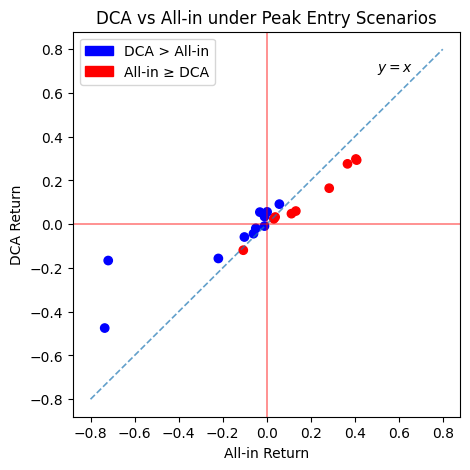

In [25]:
import matplotlib.patches as mpatches

x = np.linspace(-0.8, 0.8, 100)
y = x


plt.figure(figsize=[5, 5])
plt.plot(x, y, linestyle='--', lw=1.2, alpha=0.7)

# plt.scatter(peak_df["AllIn_Return"], peak_df["DCA_Return"], color='orange', alpha=1)
colors = peak_df["DCA_Beat_AllIn"].map({True: "blue", False: "red"})

plt.scatter(peak_df["AllIn_Return"], peak_df["DCA_Return"], c=colors)

plt.axhline(0, lw=1.2, alpha=0.5, color='r')
plt.axvline(0, lw=1.2, alpha=0.5, color='r')

plt.text(x=0.5, y=0.7, s=r"$y=x$")

plt.title("DCA vs All-in under Peak Entry Scenarios")


blue_patch = mpatches.Patch(color='blue', label='DCA > All-in')
red_patch = mpatches.Patch(color='red', label='All-in ≥ DCA')
plt.legend(handles=[blue_patch, red_patch])

plt.xlabel("All-in Return")
plt.ylabel("DCA Return")


fig_path = get_figure_path("DCA vs All-in under Peak Entry Scenarios.png", category="exploratory")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(fig_path)


plt.show()

K:\GitDocument\GitUpload\all-in-vs-dca\reports\figures\final\DCA vs All-in under Peak Entry Scenarios.png


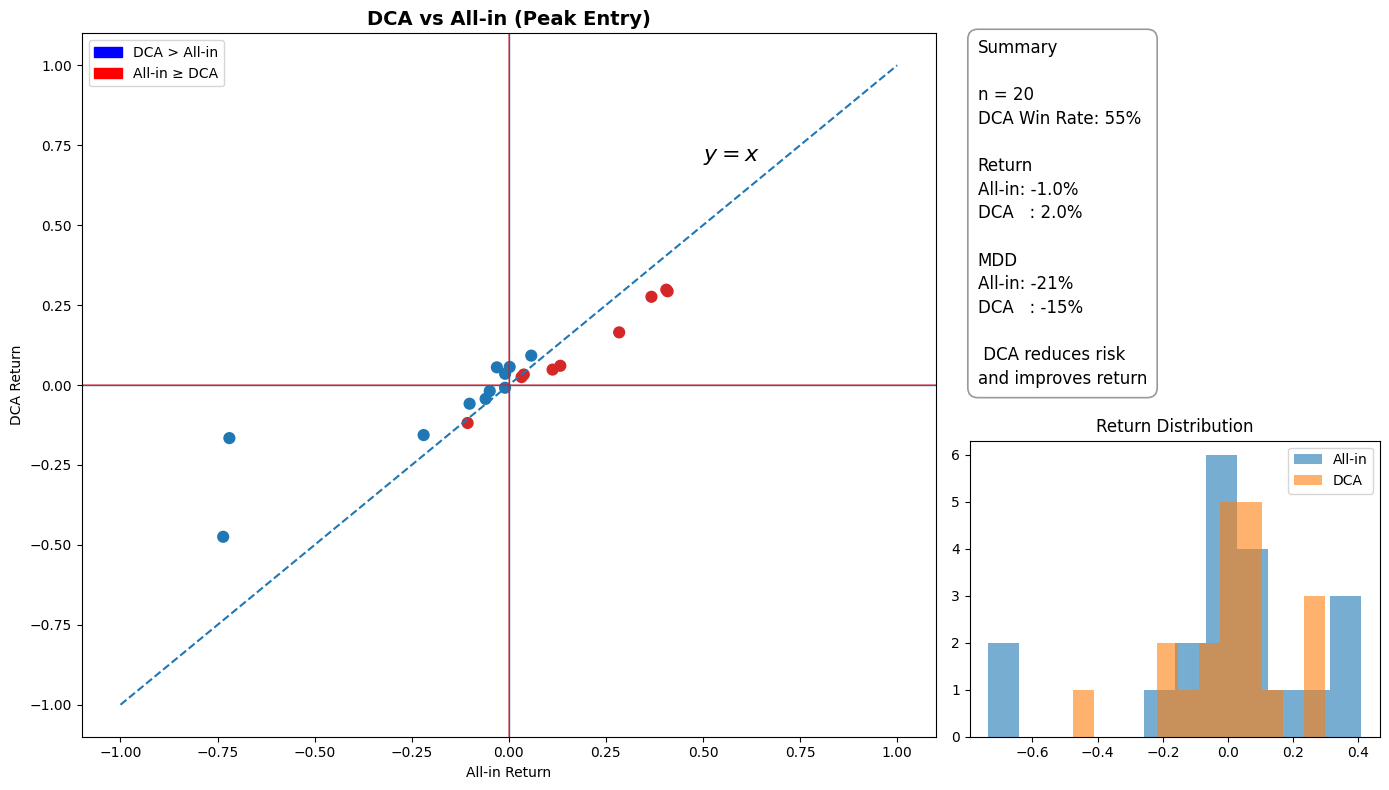

In [26]:
import matplotlib.pyplot as plt


win_rate = peak_df["DCA_Beat_AllIn"].mean()

# ===== Layout =====
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3)

# ===== 1. Scatter（主圖）=====
ax1 = fig.add_subplot(gs[0:2, 0:2])

colors = peak_df["DCA_Beat_AllIn"].map({True: "#1f77b4", False: "#d62728"})


ax1.scatter(peak_df["AllIn_Return"], peak_df["DCA_Return"], c=colors, s=60)

ax1.axhline(0, linewidth=1)
ax1.axvline(0, linewidth=1)
ax1.plot([-1,1], [-1,1], linestyle="--")

ax1.axhline(0, lw=1.2, alpha=0.5, color='r')
ax1.axvline(0, lw=1.2, alpha=0.5, color='r')

ax1.text(x=0.5, y=0.7, s=r"$y=x$", fontsize=16)


blue_patch = mpatches.Patch(color='blue', label='DCA > All-in')
red_patch = mpatches.Patch(color='red', label='All-in ≥ DCA')
ax1.legend(handles=[blue_patch, red_patch])


ax1.set_title("DCA vs All-in (Peak Entry)", fontsize=14, weight="bold")
ax1.set_xlabel("All-in Return")
ax1.set_ylabel("DCA Return")

# ===== 2. Summary（右上）=====
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis("off")


ax2 = fig.add_subplot(gs[0, 2])
ax2.axis("off")

summary = (
    "Summary\n\n"
    f"n = {len(peak_df)}\n"
    f"DCA Win Rate: {win_rate:.0%}\n\n"
    "Return\n"
    f"All-in: {peak_df['AllIn_Return'].mean():.1%}\n"
    f"DCA   : {peak_df['DCA_Return'].mean():.1%}\n\n"
    "MDD\n"
    f"All-in: {peak_df['AllIn_MDD'].mean():.0%}\n"
    f"DCA   : {peak_df['DCA_MDD'].mean():.0%}\n\n"
    " DCA reduces risk\nand improves return"
)

ax2.text(
    0.02, 0.98, summary,
    transform=ax2.transAxes,
    va="top", ha="left",
    fontsize=12,
    linespacing=1.4,   # 
    bbox=dict(
        boxstyle="round,pad=0.6",  # padding
        facecolor="white",
        edgecolor="#999999",
        linewidth=1.2
    )
)


# ax2.text(0, 1, summary, va="top", fontsize=11)

# ===== 3️. Return 分布 =====
ax3 = fig.add_subplot(gs[1, 2])

ax3.hist(peak_df["AllIn_Return"], bins=12, alpha=0.6, label="All-in")
ax3.hist(peak_df["DCA_Return"], bins=12, alpha=0.6, label="DCA")

ax3.set_title("Return Distribution")
ax3.legend()

# # ===== 4️. MDD 分布 =====
# ax4 = fig.add_subplot(gs[1, 2])

# ax4.hist(peak_df["AllIn_MDD"], bins=12, alpha=0.6, label="All-in")
# ax4.hist(peak_df["DCA_MDD"], bins=12, alpha=0.6, label="DCA")

# ax4.set_title("Max Drawdown")
# ax4.legend()


# ===== spacing =====
plt.tight_layout()

# ===== Save Figure =====
fig_path = get_figure_path("DCA vs All-in under Peak Entry Scenarios.png", category="final")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(fig_path)

plt.show()



In [27]:
peak_df

,Base_Date,Entry_Date,Exit_Date,Holding_TradeDays,Holding_Years_Approx,n_splits,gap_days,AllIn_Return,AllIn_MDD,DCA_Return,DCA_MDD,DCA_Beat_AllIn,Return_Diff,MDD_Diff
0,2010-01-11,2010-01-11,2010-07-08,120,0.48,3,30,-0.101036,-0.167875,-0.058479,-0.138104,True,0.042557,2.977174e-02
1,2010-10-07,2010-10-07,2011-04-01,120,0.48,3,30,0.032787,-0.090476,0.024861,-0.090476,False,-0.007926,0.000000e+00
2,2010-12-09,2010-12-09,2011-06-09,120,0.48,3,30,0.038526,-0.090476,0.032875,-0.069364,False,-0.005651,2.111219e-02
3,2011-01-28,2011-01-28,2011-07-29,120,0.48,3,30,-0.049206,-0.090476,-0.018871,-0.075381,True,0.030335,1.509502e-02
4,2013-02-20,2013-02-20,2013-08-13,120,0.48,3,30,-0.009804,-0.097104,-0.008468,-0.095129,True,0.001336,1.975075e-03
5,2013-05-16,2013-05-16,2013-11-06,120,0.48,3,30,-0.009590,-0.097104,0.035152,-0.044323,True,0.044742,5.278114e-02
6,2013-10-30,2013-10-30,2014-04-28,120,0.48,3,30,-0.735535,-0.762755,-0.474611,-0.526406,True,0.260924,2.363487e-01
7,2013-12-30,2013-12-30,2014-06-30,120,0.48,3,30,-0.719600,-0.762755,-0.166026,-0.254496,True,0.553574,5.082591e-01
8,2021-07-15,2021-07-15,2022-01-04,120,0.48,3,30,0.057705,-0.075568,0.091919,-0.048957,True,0.034214,2.661162e-02
9,2021-09-06,2021-09-06,2022-03-08,120,0.48,3,30,-0.059793,-0.118247,-0.043283,-0.118247,True,0.016510,0.000000e+00


K:\GitDocument\GitUpload\all-in-vs-dca\reports\figures\final\DCA vs All-in under Peak Entry Dashboard.png


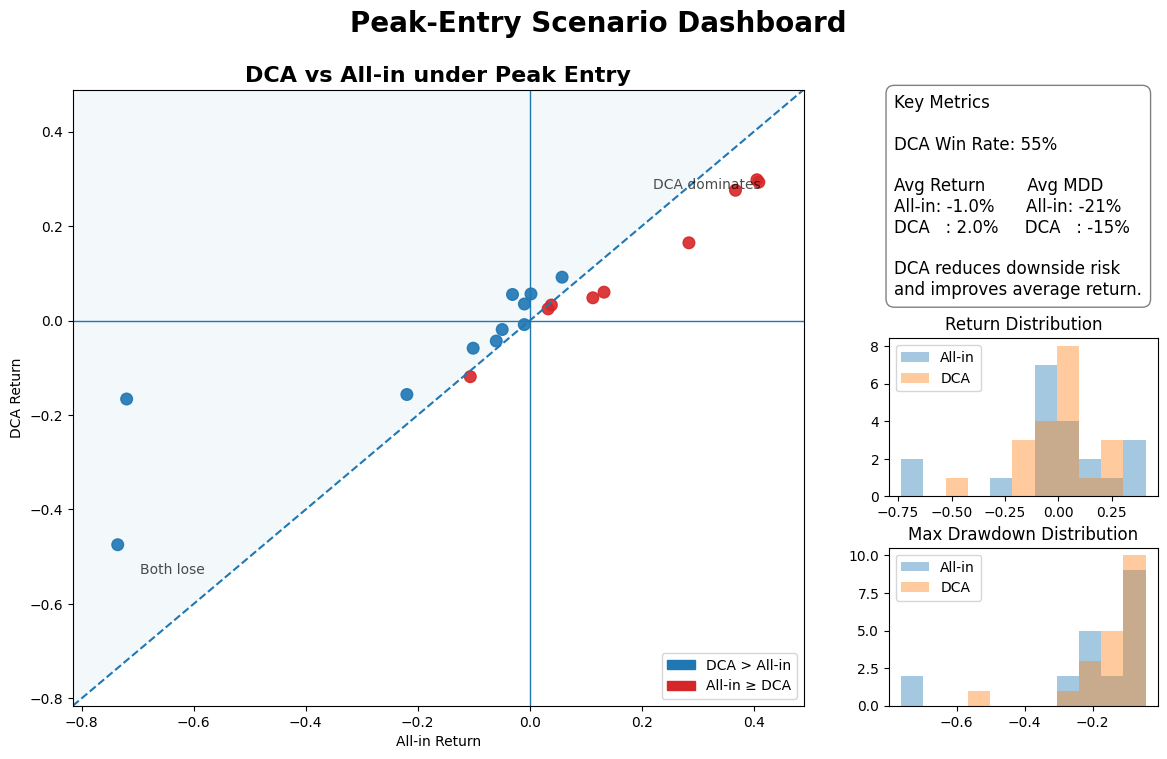

In [28]:
import matplotlib.patches as mpatches
import numpy as np

# df = peak_df.copy()
# df["Return_Diff"] = df["DCA_Return"] - df["AllIn_Return"]
# df["MDD_Diff"] = df["DCA_MDD"] - df["AllIn_MDD"]

win_rate = peak_df["DCA_Beat_AllIn"].mean()

# ===== Layout =====
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(
    3, 3,
    width_ratios=[1.2, 1.2, 1.0],
    height_ratios=[1.25, 1.0, 1.0],
    wspace=0.28,
    hspace=0.30
)

# ===== 1) Scatter（主圖）=====
ax1 = fig.add_subplot(gs[:, 0:2])

colors = peak_df["DCA_Beat_AllIn"].map({True: "#1f77b4", False: "#d62728"})

ax1.scatter(peak_df["AllIn_Return"], peak_df["DCA_Return"], c=colors, s=70, alpha=0.9)

# 自動設定範圍，避免留太多空白
xy_min = min(peak_df["AllIn_Return"].min(), peak_df["DCA_Return"].min())
xy_max = max(peak_df["AllIn_Return"].max(), peak_df["DCA_Return"].max())
pad = 0.08
lo = xy_min - pad
hi = xy_max + pad

ax1.axhline(0, linewidth=1)
ax1.axvline(0, linewidth=1)
ax1.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5)

ax1.set_xlim(lo, hi)
ax1.set_ylim(lo, hi)

ax1.set_title("DCA vs All-in under Peak Entry", fontsize=16, weight="bold")
ax1.set_xlabel("All-in Return")
ax1.set_ylabel("DCA Return")

blue_patch = mpatches.Patch(color="#1f77b4", label="DCA > All-in")
red_patch = mpatches.Patch(color="#d62728", label="All-in ≥ DCA")
ax1.legend(handles=[blue_patch, red_patch], loc="lower right", frameon=True)

ax1.fill_between(
    [lo, hi],
    [lo, hi],
    hi,
    alpha=0.05
)

# 可選：區域標註
ax1.text(lo + 0.12, lo + 0.28, "Both lose", fontsize=10, alpha=0.7)
ax1.text(0.22, 0.28, "DCA dominates", fontsize=10, alpha=0.7)

# ===== 2) Summary（右上）=====
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis("off")

summary = (
    "Key Metrics\n\n"
    f"DCA Win Rate: {win_rate:.0%}\n\n"
    f"Avg Return" + "        Avg MDD\n"
    f"All-in: {peak_df['AllIn_Return'].mean():.1%}"  + f"      All-in: {peak_df['AllIn_MDD'].mean():.0%}\n"
    f"DCA   : {peak_df['DCA_Return'].mean():.1%}"    + f"     DCA   : {peak_df['DCA_MDD'].mean():.0%}\n\n"
    # f"Avg MDD\n"
    # f"All-in: {peak_df['AllIn_MDD'].mean():.0%}\n"
    # f"DCA   : {peak_df['DCA_MDD'].mean():.0%}\n\n"
    # "Takeaway\n"
    "DCA reduces downside risk\n"
    "and improves average return."
    # "under peak entry"
)

ax2.text(
    0.02, 0.98, summary,
    transform=ax2.transAxes,
    va="top", ha="left",
    fontsize=12,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray"
    )
)
# summary = (
#     "Key Metrics\n\n"
#     f"DCA Win Rate: {win_rate:.0%}\n\n"
#     f"Avg Return\n"
#     f"All-in: {df['AllIn_Return'].mean():.1%}\n"
#     f"DCA   : {df['DCA_Return'].mean():.1%}\n\n"
#     f"Avg MDD\n"
#     f"All-in: {df['AllIn_MDD'].mean():.0%}\n"
#     f"DCA   : {df['DCA_MDD'].mean():.0%}"
# )
# ax2.text(
#     0.02, -0.05,
#     "DCA reduces downside risk\nand improves average return\nunder peak entry",
#     transform=ax2.transAxes,
#     fontsize=11,
#     weight="bold"
# )

# summary = (
#     "Summary\n\n"
#     f"Samples: {len(peak_df)}\n"
#     f"DCA Win Rate: {win_rate:.0%}\n\n"
#     "Avg Return\n"
#     f"All-in: {peak_df['AllIn_Return'].mean():.2%}\n"
#     f"DCA   : {peak_df['DCA_Return'].mean():.2%}\n\n"
#     "Avg MDD\n"
#     f"All-in: {peak_df['AllIn_MDD'].mean():.2%}\n"
#     f"DCA   : {peak_df['DCA_MDD'].mean():.2%}\n\n"
#     "Advantage\n"
#     f"Return: {peak_df['Return_Diff'].mean():.2%}\n"
#     f"MDD   : {peak_df['MDD_Diff'].mean():.2%}"
# )

# ax2.text(
#     0.02, 0.98, summary,
#     transform=ax2.transAxes,
#     va="top", ha="left",
#     fontsize=10,
#     bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray")
# )

# ===== 3) Return 分布（右中）=====
ax3 = fig.add_subplot(gs[1, 2])

ret_min = min(peak_df["AllIn_Return"].min(), peak_df["DCA_Return"].min())
ret_max = max(peak_df["AllIn_Return"].max(), peak_df["DCA_Return"].max())
ret_bins = np.linspace(ret_min, ret_max, 12)

ax3.hist(peak_df["AllIn_Return"], bins=ret_bins, alpha=0.4, label="All-in")
ax3.hist(peak_df["DCA_Return"], bins=ret_bins, alpha=0.4, label="DCA")
ax3.set_title("Return Distribution", fontsize=12)
ax3.legend(frameon=True)

# ===== 4) MDD 分布（右下）=====
ax4 = fig.add_subplot(gs[2, 2])

mdd_min = min(peak_df["AllIn_MDD"].min(), peak_df["DCA_MDD"].min())
mdd_max = max(peak_df["AllIn_MDD"].max(), peak_df["DCA_MDD"].max())
mdd_bins = np.linspace(mdd_min, mdd_max, 12)

ax4.hist(peak_df["AllIn_MDD"], bins=mdd_bins, alpha=0.4, label="All-in")
ax4.hist(peak_df["DCA_MDD"], bins=mdd_bins, alpha=0.4, label="DCA")
ax4.set_title("Max Drawdown Distribution", fontsize=12)
ax4.legend(frameon=True)

fig.suptitle("Peak-Entry Scenario Dashboard", fontsize=20, weight="bold", y=0.98)


# ===== Save Figure =====
fig_path = get_figure_path("DCA vs All-in under Peak Entry Dashboard.png", category="final")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(fig_path)

plt.show()

### Key Findings from Peak-Entry Analysis

- When entering near market peaks:
  - **All-in** tends to suffer larger drawdowns
  - **DCA** provides stronger downside protection
- Entry timing risk plays a critical role in relative strategy performance

In peak-entry scenarios such as entries near recent one-year highs, DCA not only reduces maximum drawdown and extreme loss risk, but can also produce a higher average return.

This suggests that DCA is especially useful when the investor is uncertain about short-term valuation or fears buying too close to a local top.


## 6. Long-Horizon Monte Carlo Simulation under the Overall Market

In this section, we no longer condition on a special market state.  
Instead, we simulate future log-return paths from the **overall market distribution** using both:

- **Geometric Brownian Motion (GBM)**
- **Bootstrap**



The goal is to compare:

- the probability that DCA outperforms All-in
- the average return difference between the two strategies
- whether the relative result changes across investment horizons

We evaluate horizons such as **3, 5, 10, 20, and 30 years** to see whether time diversification changes the conclusion.


### 6.1 Simulation Methods

#### 6.1.1 Geometric Brownian Motion (GBM)

Under GBM, daily log returns are assumed to follow a normal distribution:

$$
r_t \sim \mathcal{N}(\mu, \sigma^2)
$$

This is the standard parametric benchmark in finance.  
It is simple, interpretable, and useful for understanding long-run behavior under constant drift and volatility.

#### 6.1.2 Bootstrap

The bootstrap method resamples historical daily returns with replacement.

Its main advantage is that it preserves more of the **empirical distribution** than GBM, including asymmetry or multi-modality present in the historical sample.

### Why Monte Carlo?

- Market path is uncertain
- Closed-form solution not available
- Allows distribution-level comparison (not just mean)

### Why use both?
Using both methods helps separate two questions:

- Are the conclusions driven by a **strong parametric assumption**?
- Or do they remain similar under a more **data-driven resampling approach**?


### 6.2 Parameter Setting

- `horizons = [3, 5, 10, 20, 30]`  
  Investment horizons after the initial All-in or DCA deployment

- `n_sims = 100_000`  
  Number of simulated future paths

- `method = "bootstrap"` or `"gbm"`  
  Simulation engine

- `rf_annual = 0.0141`  
  Annual risk-free rate used for Sharpe / Sortino-style evaluation

- `mar_annual = 0.09`  
  Minimum acceptable return (MAR) used in downside-risk measurement

- `batch_size`  
  Used to control memory usage during large-scale simulation

### Risk metric note
In addition to standard volatility, this project also evaluates **downside deviation**, which focuses only on returns below the minimum acceptable return.

That makes the risk comparison more aligned with how many investors actually experience risk:  
they care more about **bad volatility** than upside volatility.


In [29]:
from main import run_long_horizon_mc

horizons = [3, 5, 10, 20, 30]

MC_PARAMS_BGM = {
    "ticker":ticker,
    "start":start,
    "end":end,
    "horizons": horizons,
    "n_sims": 100_000,
    "method": "gbm",
    "dca_months": 12,
    "ticker":ticker,
    "rf_annual": 0.0141, # 設定一個合理的無風險利率(rf_annual)，此處取10年期美國公債殖利率，來計算夏普比率。這樣可以更貼近投資者的機會成本，而不是假設 rf=0。
    "mar_annual": 0.09, # 可以設定一個合理的 MAR（Minimum Acceptable Return），例如 CAPM 預期報酬率或 0% 實質報酬率，來計算下行風險(MAR ratio)。這樣可以更貼近投資者的風險偏好，而不是單純看波動率。
    "seed": 42,
    "batch_size": 10_000,
    "save_outputs": True,
    "output_category": "final"
}


mc_results_bgm = run_long_horizon_mc(df, **MC_PARAMS_BGM)

=== Long Horizon MC Summary ===
   horizon_years method  n_sims  dca_months  expected_cagr_all_in  \
0              3    gbm  100000          12              0.110827   
1              5    gbm  100000          12              0.098781   
2             10    gbm  100000          12              0.090150   
3             20    gbm  100000          12              0.085868   
4             30    gbm  100000          12              0.084432   

   expected_cagr_dca  expected_terminal_all_in  expected_terminal_dca  \
0           0.096455                  1.610067               1.498622   
1           0.091726                  2.204506               2.053030   
2           0.087268                  4.844076               4.515269   
3           0.084528                 23.767120              22.146919   
4           0.083554                114.958443             106.798340   

   p_dca_beats_all_in_terminal  p_dca_beats_all_in_cagr  ann_geo_return_hist  \
0                      0.44771    

In [30]:
MC_PARAMS_BSP = {
    "ticker":ticker,
    "start":start,
    "end":end,
    "horizons": horizons,
    "n_sims": 100_000,
    "method": "bootstrap",
    "dca_months": 12,
    "ticker":ticker,
    "rf_annual": 0.0141,
    "mar_annual": 0.09,
    "seed": 42,
    "batch_size": 10_000,
    "save_outputs": True,
    "output_category": "final"
}


mc_results_bootstrap = run_long_horizon_mc(df, **MC_PARAMS_BSP)

=== Long Horizon MC Summary ===
   horizon_years     method  n_sims  dca_months  expected_cagr_all_in  \
0              3  bootstrap  100000          12              0.108963   
1              5  bootstrap  100000          12              0.098810   
2             10  bootstrap  100000          12              0.090218   
3             20  bootstrap  100000          12              0.085971   
4             30  bootstrap  100000          12              0.084767   

   expected_cagr_dca  expected_terminal_all_in  expected_terminal_dca  \
0           0.094698                  1.522718               1.429435   
1           0.091485                  2.012435               1.888179   
2           0.087090                  4.030128               3.782430   
3           0.084615                 16.253044              15.266940   
4           0.083876                 65.274422              61.394669   

   p_dca_beats_all_in_terminal  p_dca_beats_all_in_cagr  ann_geo_return_hist  \
0         

In [31]:
import base64
from IPython.display import HTML, Image, display

def show_side_by_side(paths, width=500):
    imgs_html = []
    for p in paths:
        with open(p, "rb") as f:
            b64 = base64.b64encode(f.read()).decode("utf-8")
        imgs_html.append(
            f'<img src="data:image/png;base64,{b64}" width="{width}">'
        )

    html = f"""
    <div style="display:flex; gap:10px; align-items:flex-start;">
        {''.join(imgs_html)}
    </div>
    """
    display(HTML(html))

### 6.3 Simulation Results: Distributional Interpretation

#### 3-year horizon
For both **GBM** and **Bootstrap**, All-in tends to show the higher average CAGR.

- Under **GBM**
  - The distribution is typically unimodal and left-skewed
  - DCA's distribution is narrower, suggesting lower dispersion
  - Both strategies still retain meaningful downside probability over a 3-year horizon

- Under **Bootstrap**
  - The distribution can become multi-modal
  - All-in often has a thicker right tail and left tail
  - DCA gives up some upside but reduces the severity of bad short-term paths

### General interpretation
Across simulated long-horizon paths, the same broad pattern remains:

- **All-in** tends to dominate in expected return
- **DCA** tends to reduce downside concentration
- The benefit of DCA is strongest when the main concern is **path risk**, not mean return




-------------------- Year: 3 --------------------



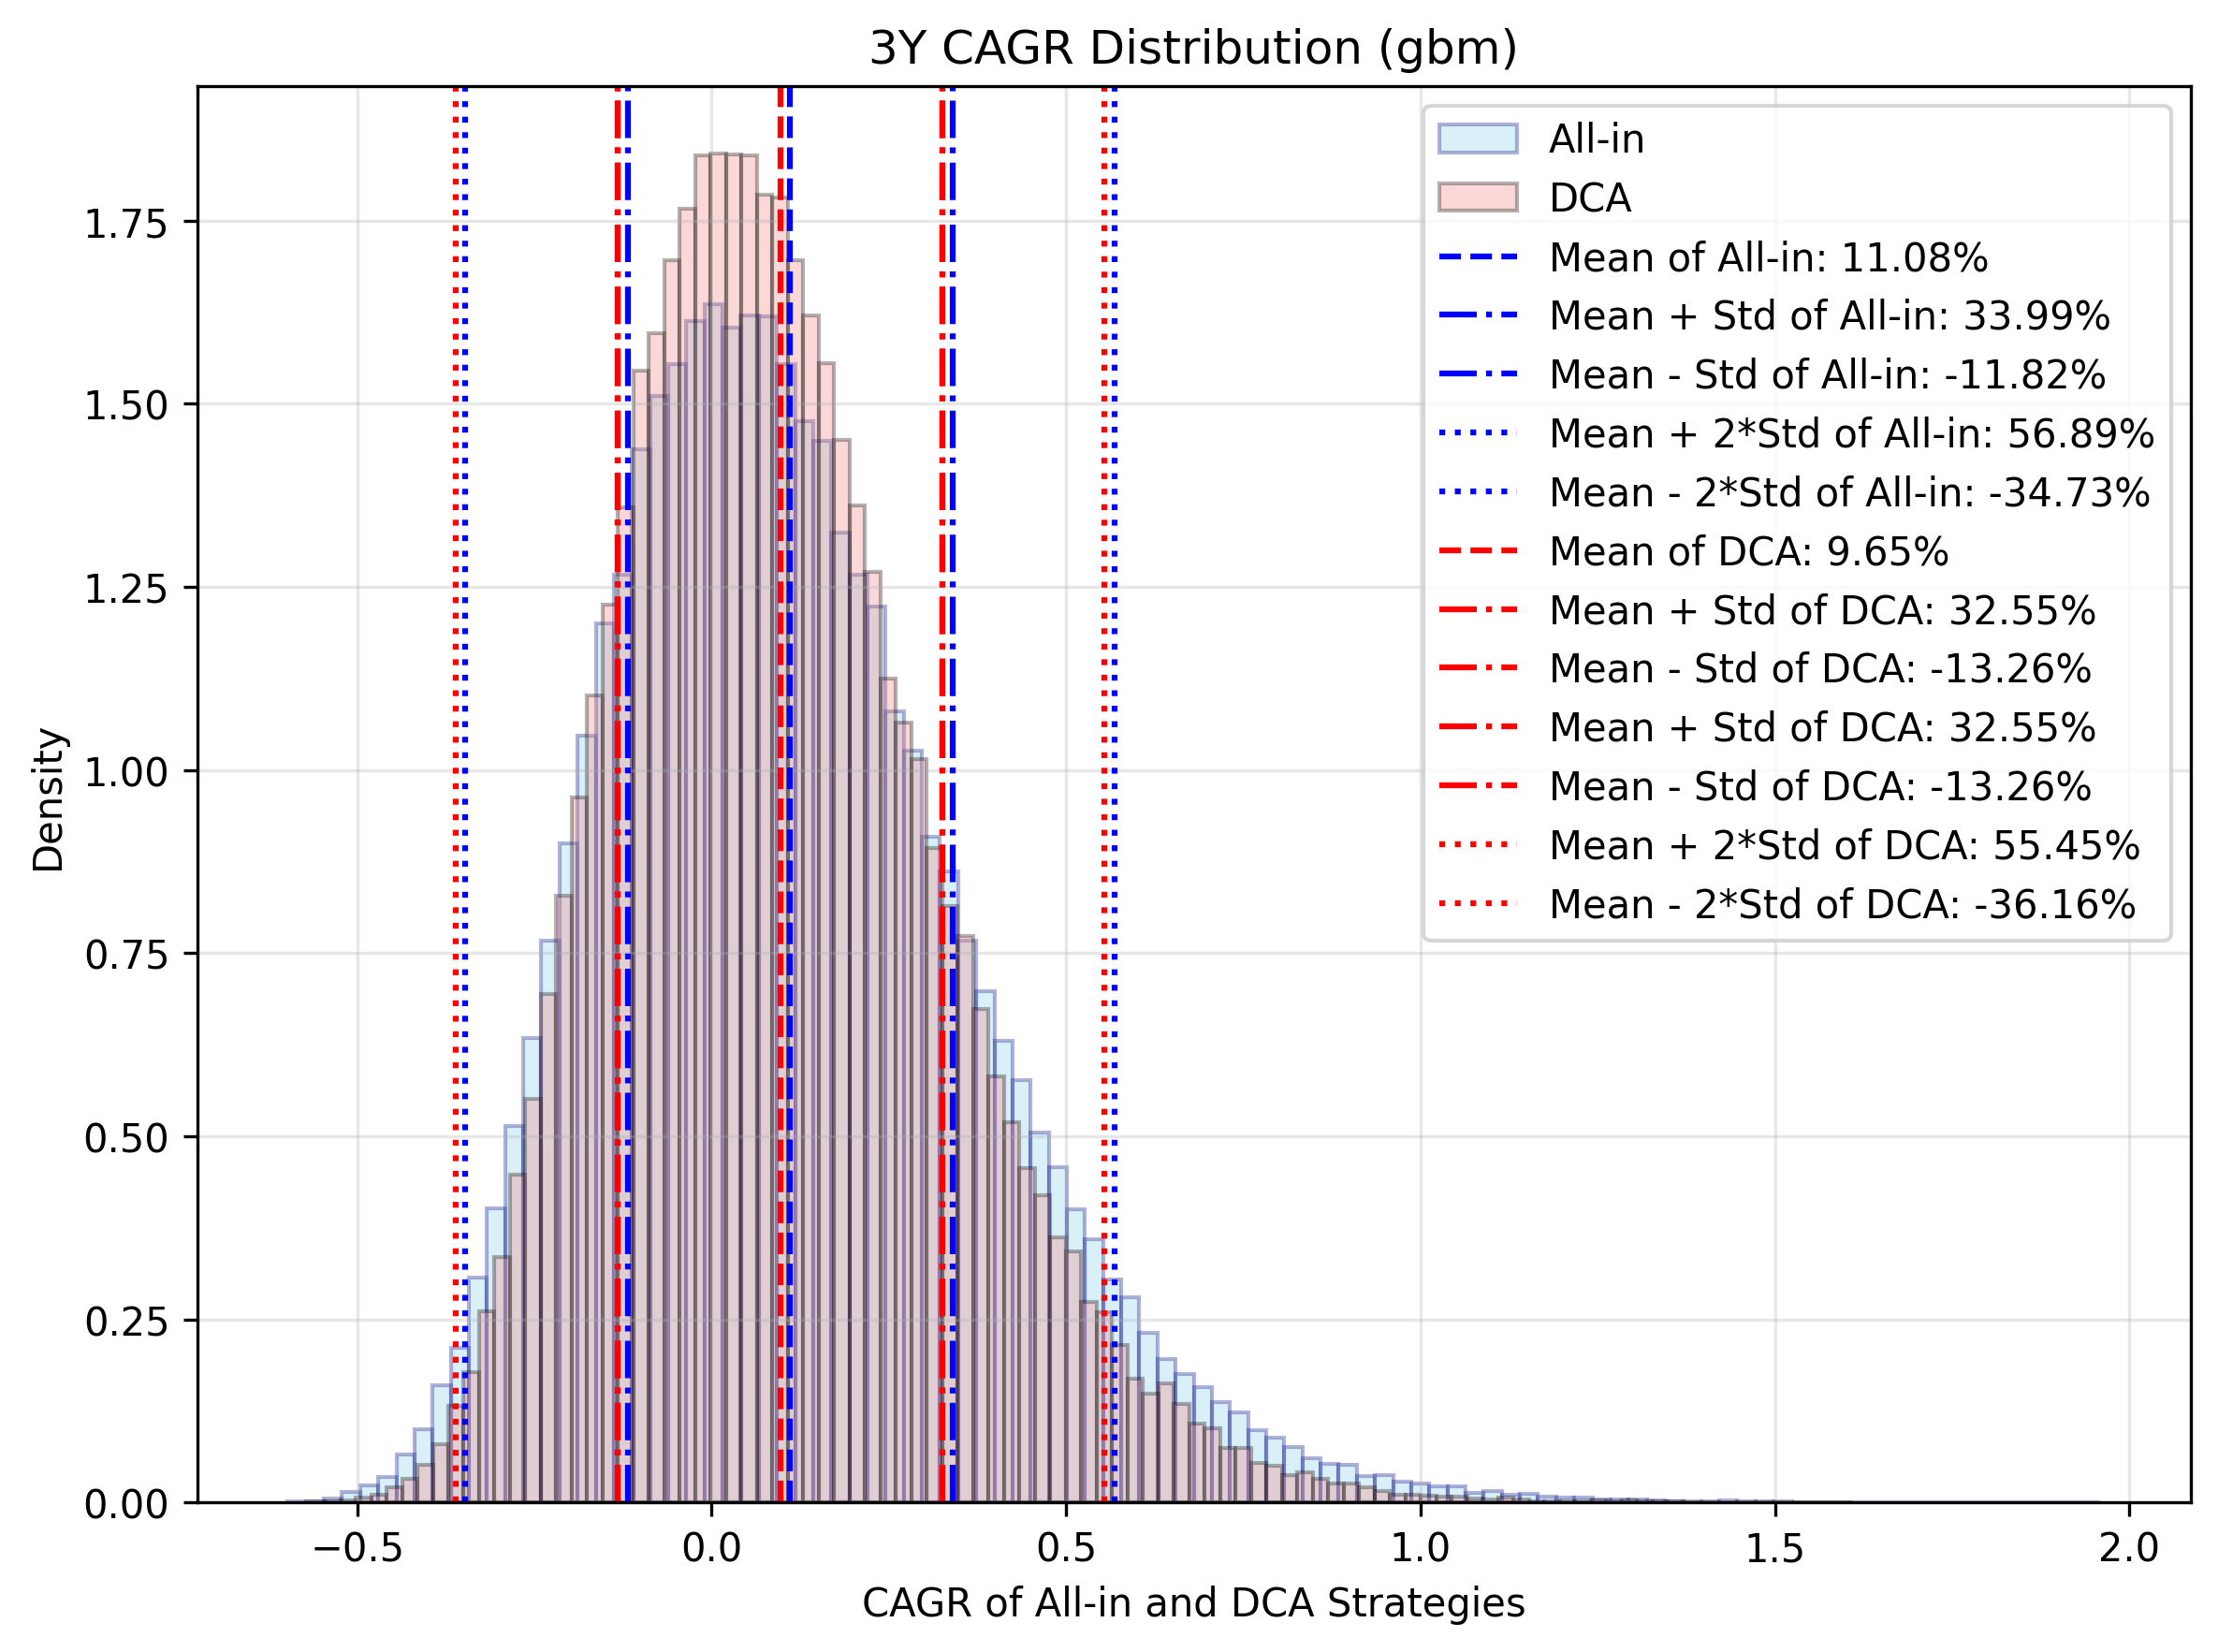
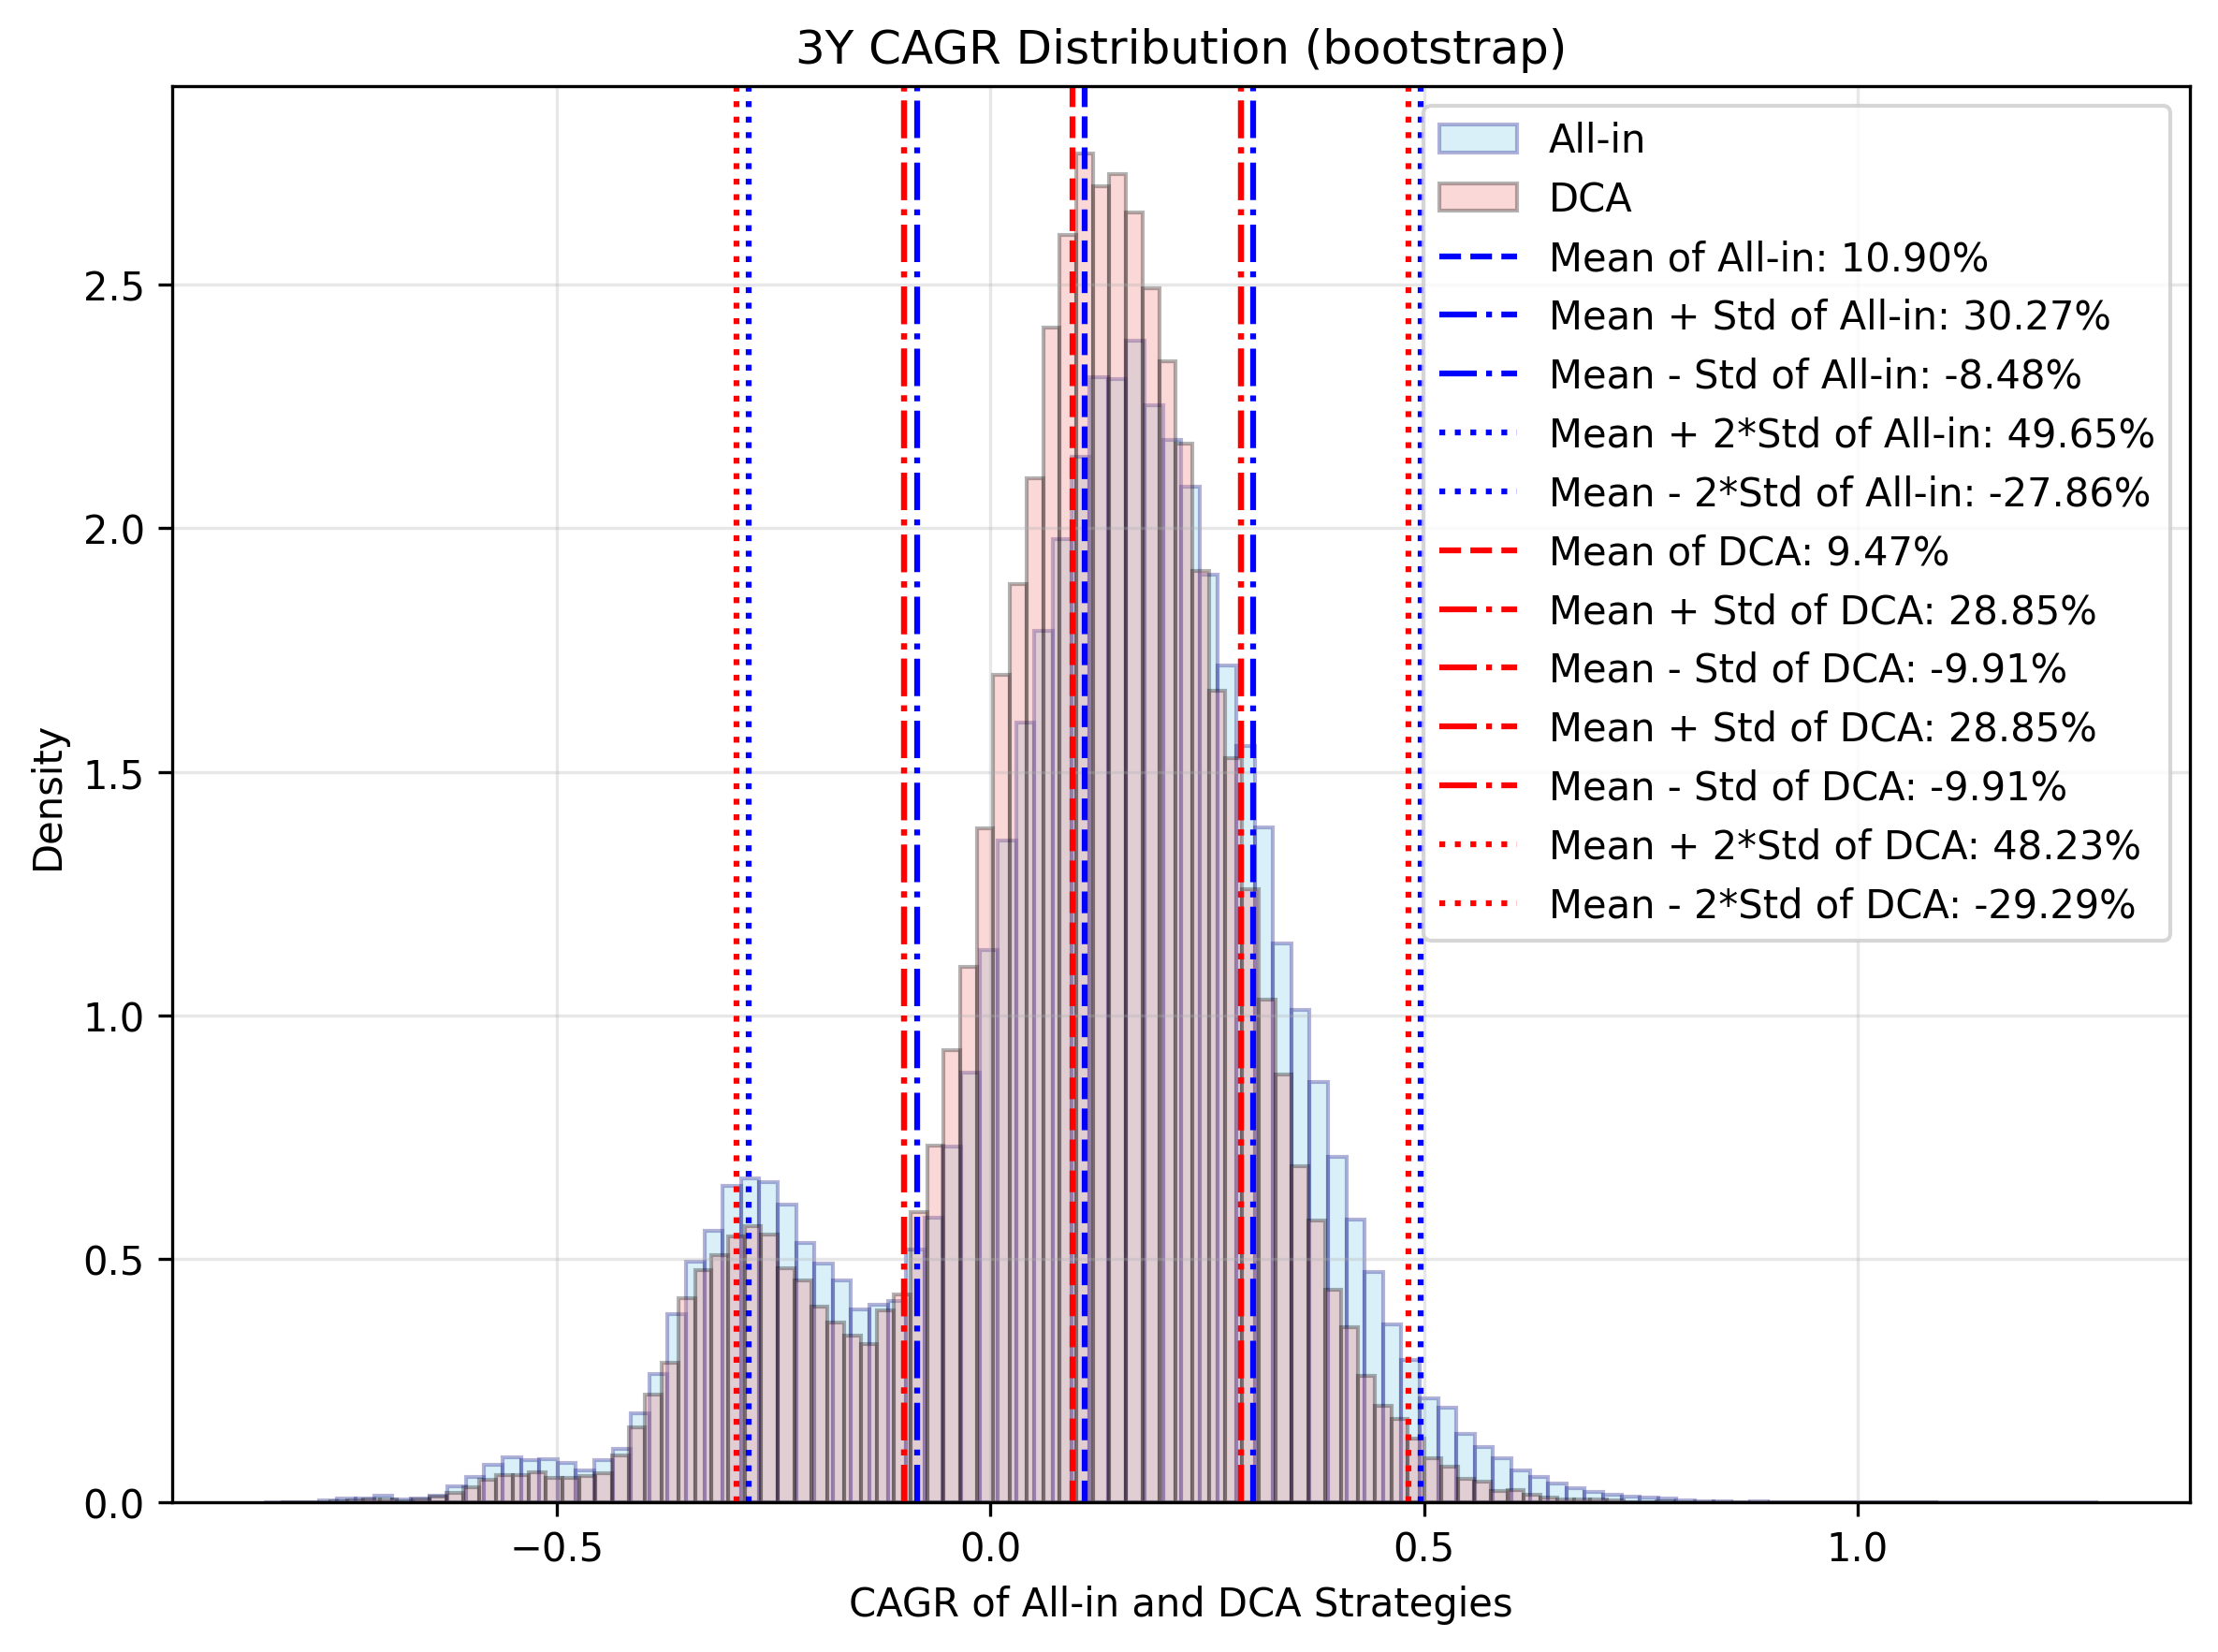



-------------------- Year: 5 --------------------



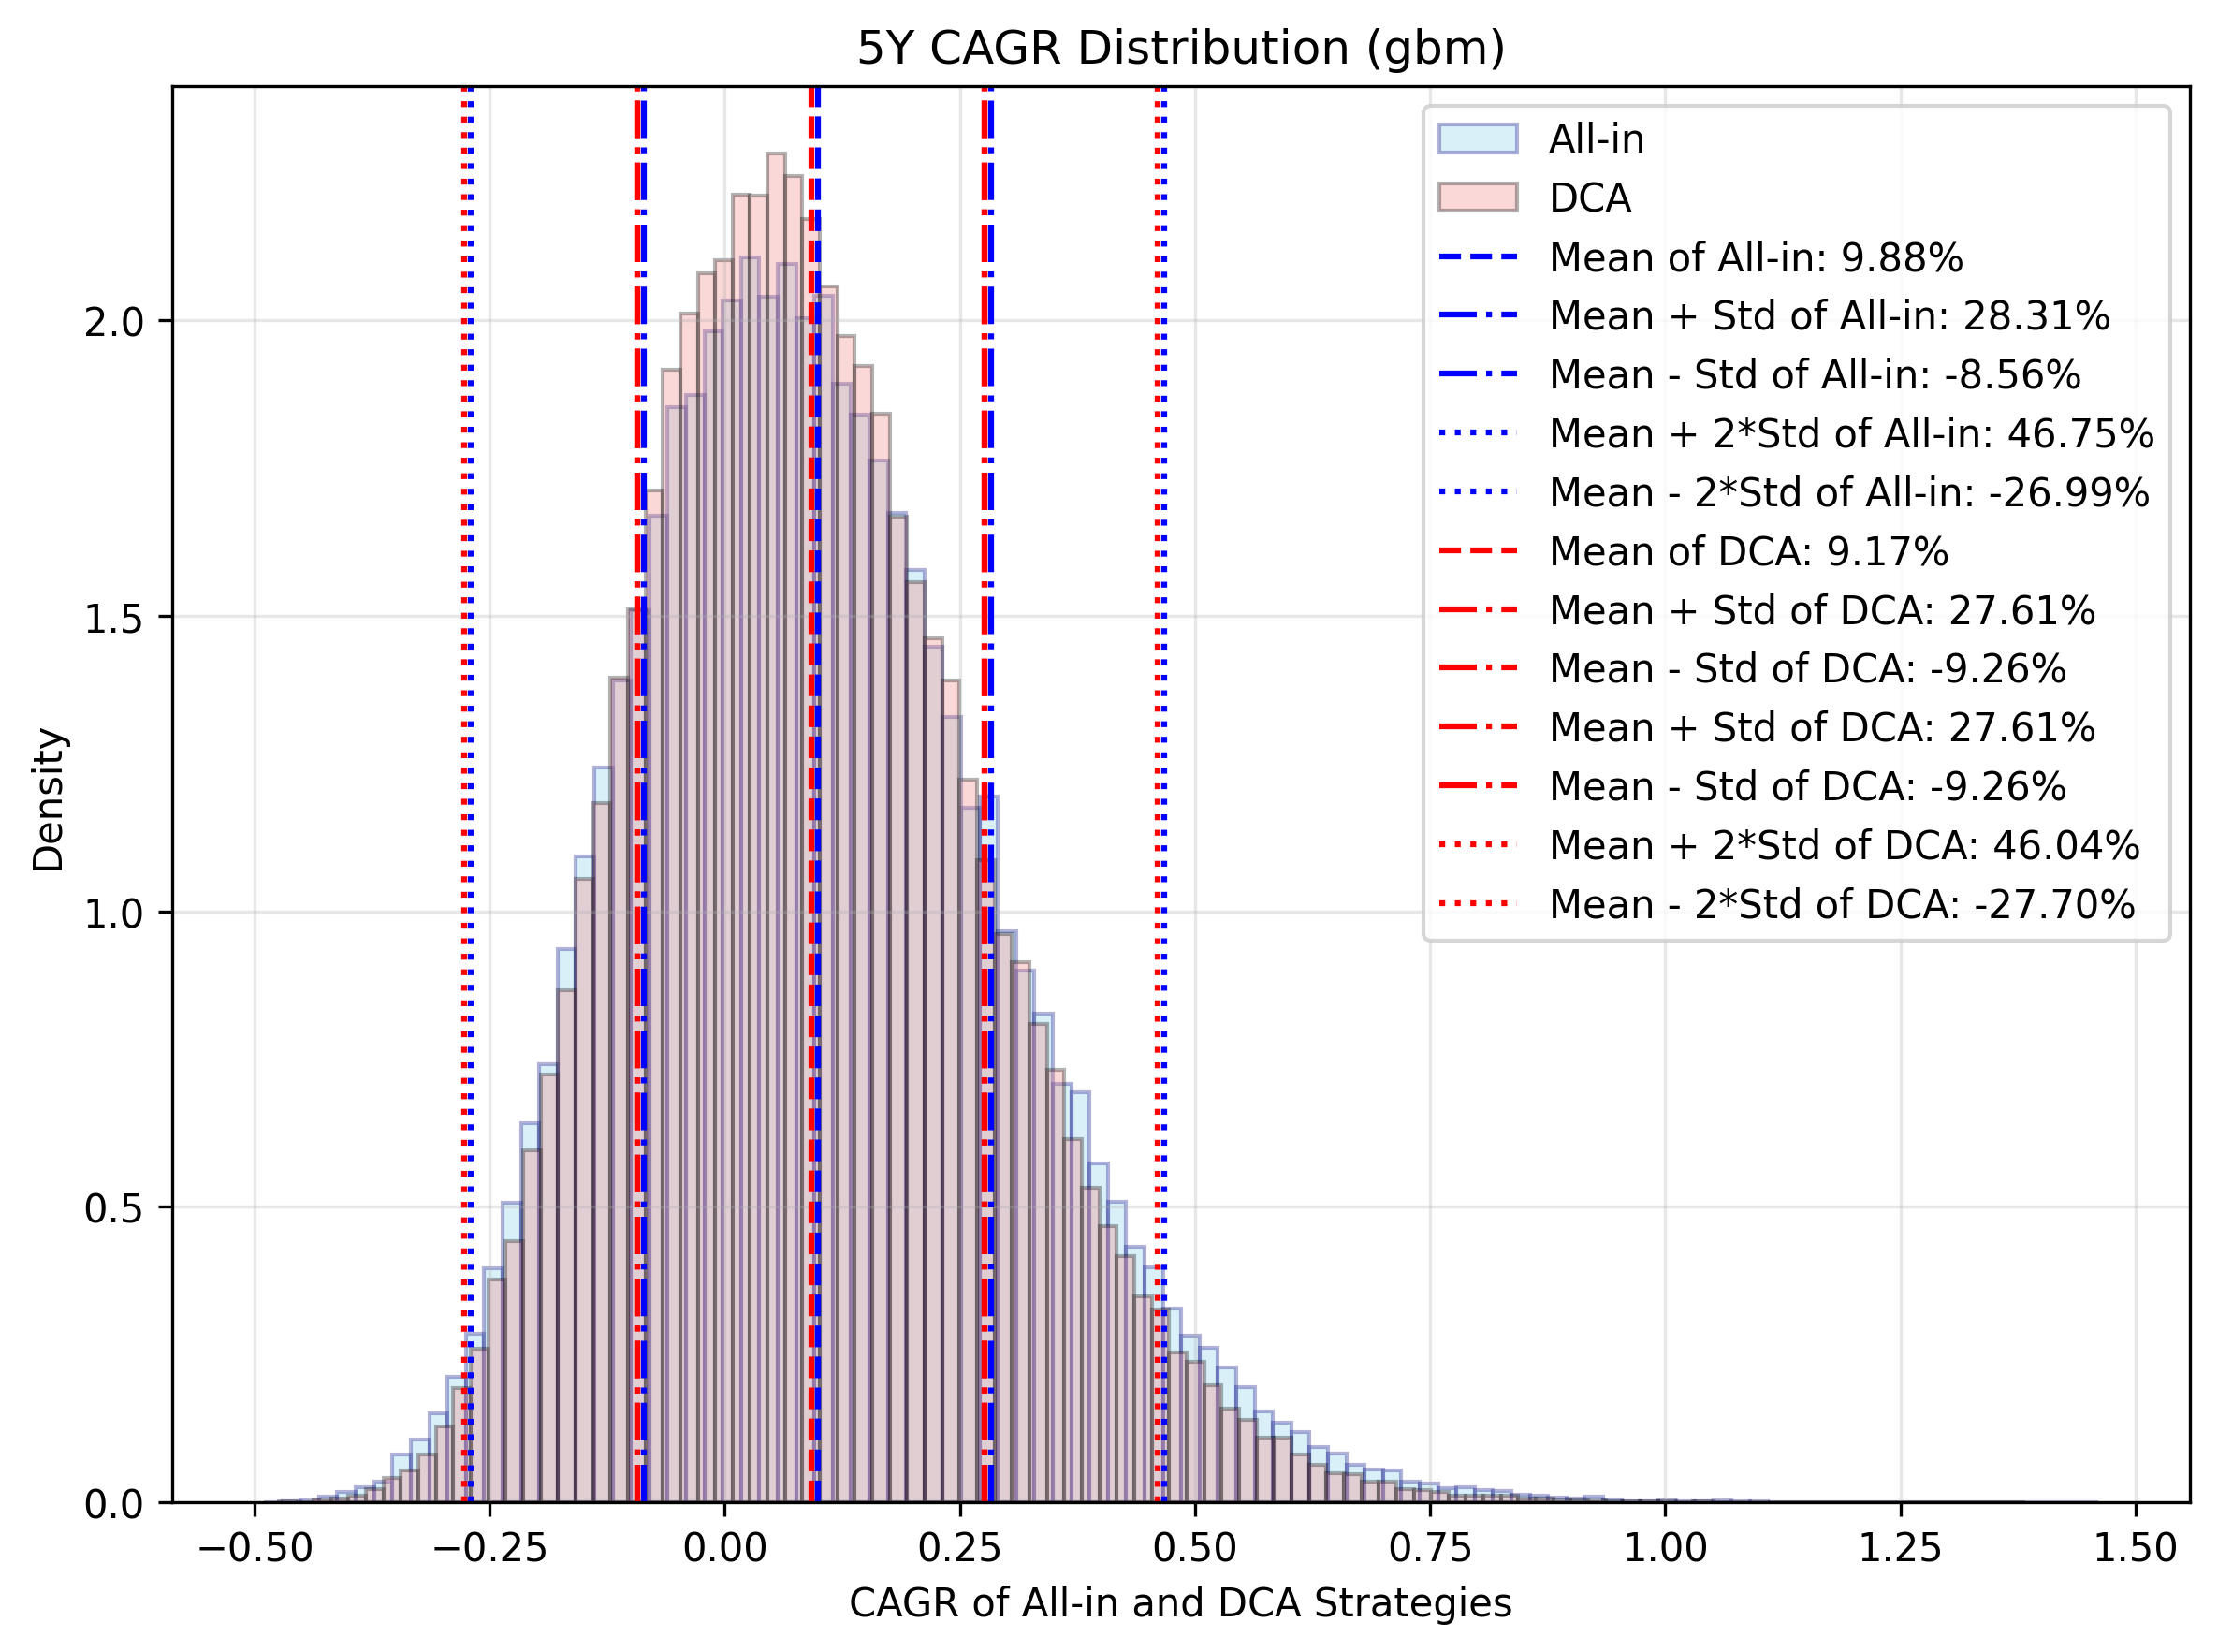
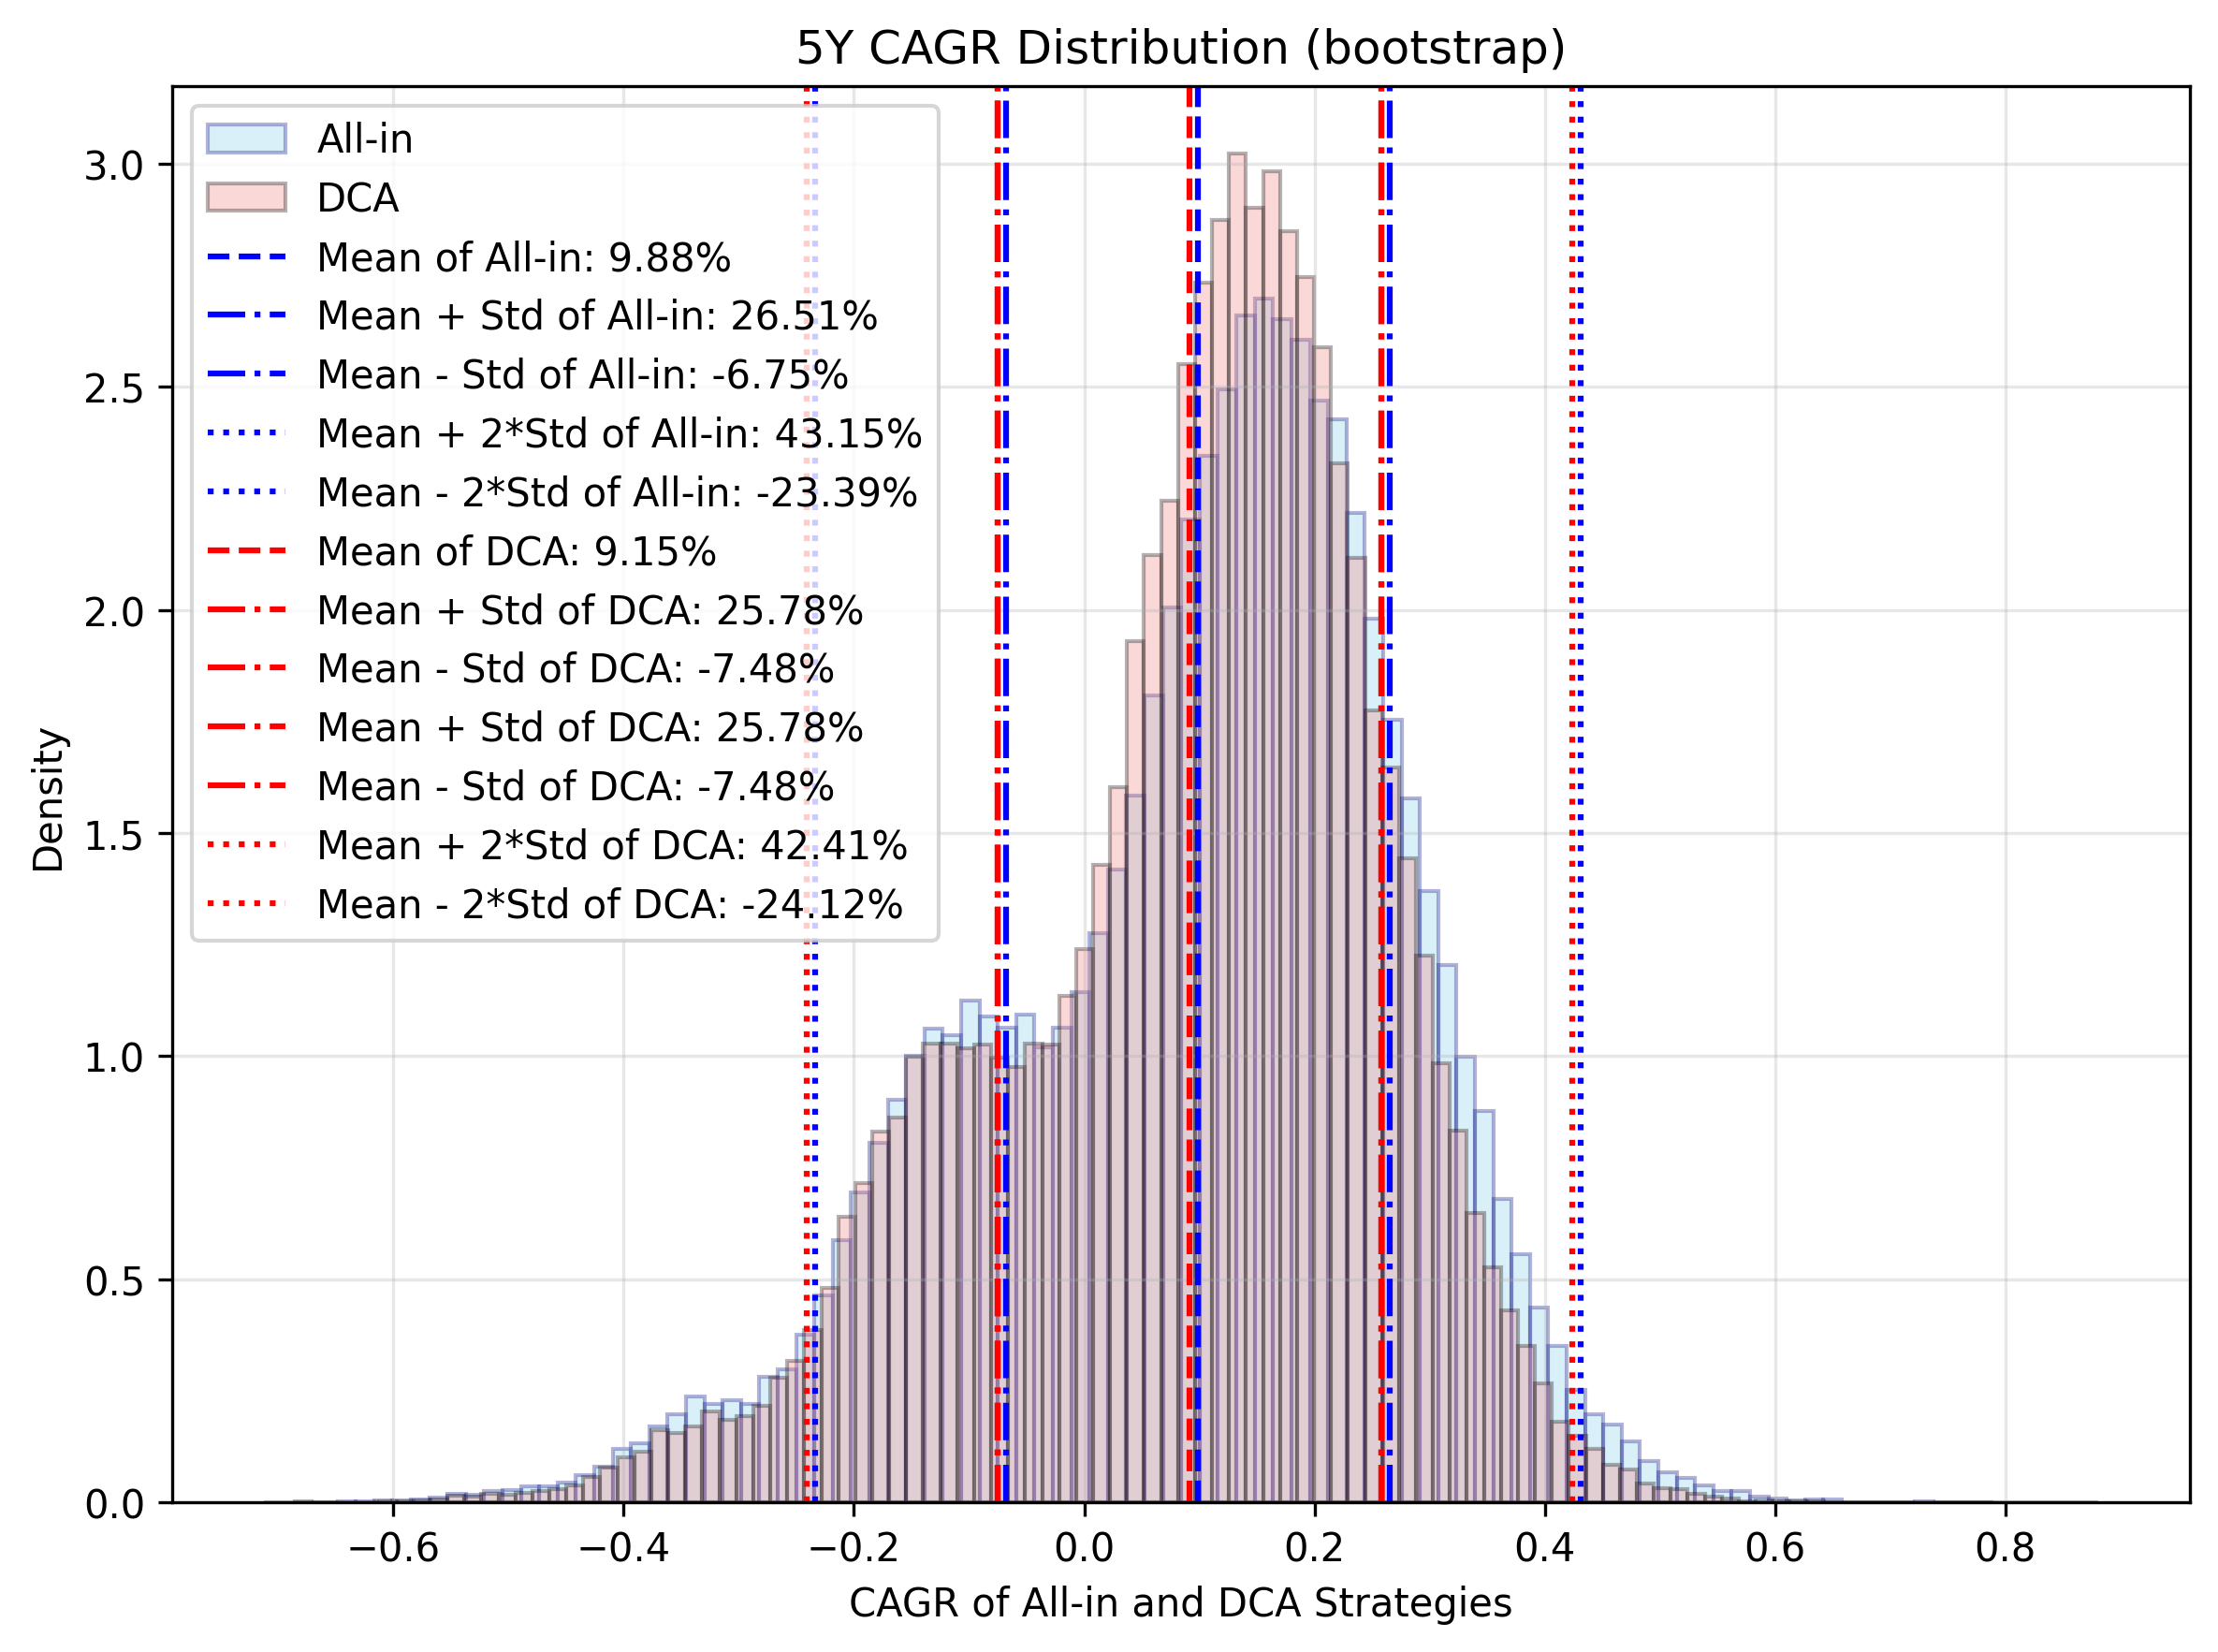



-------------------- Year: 10 --------------------



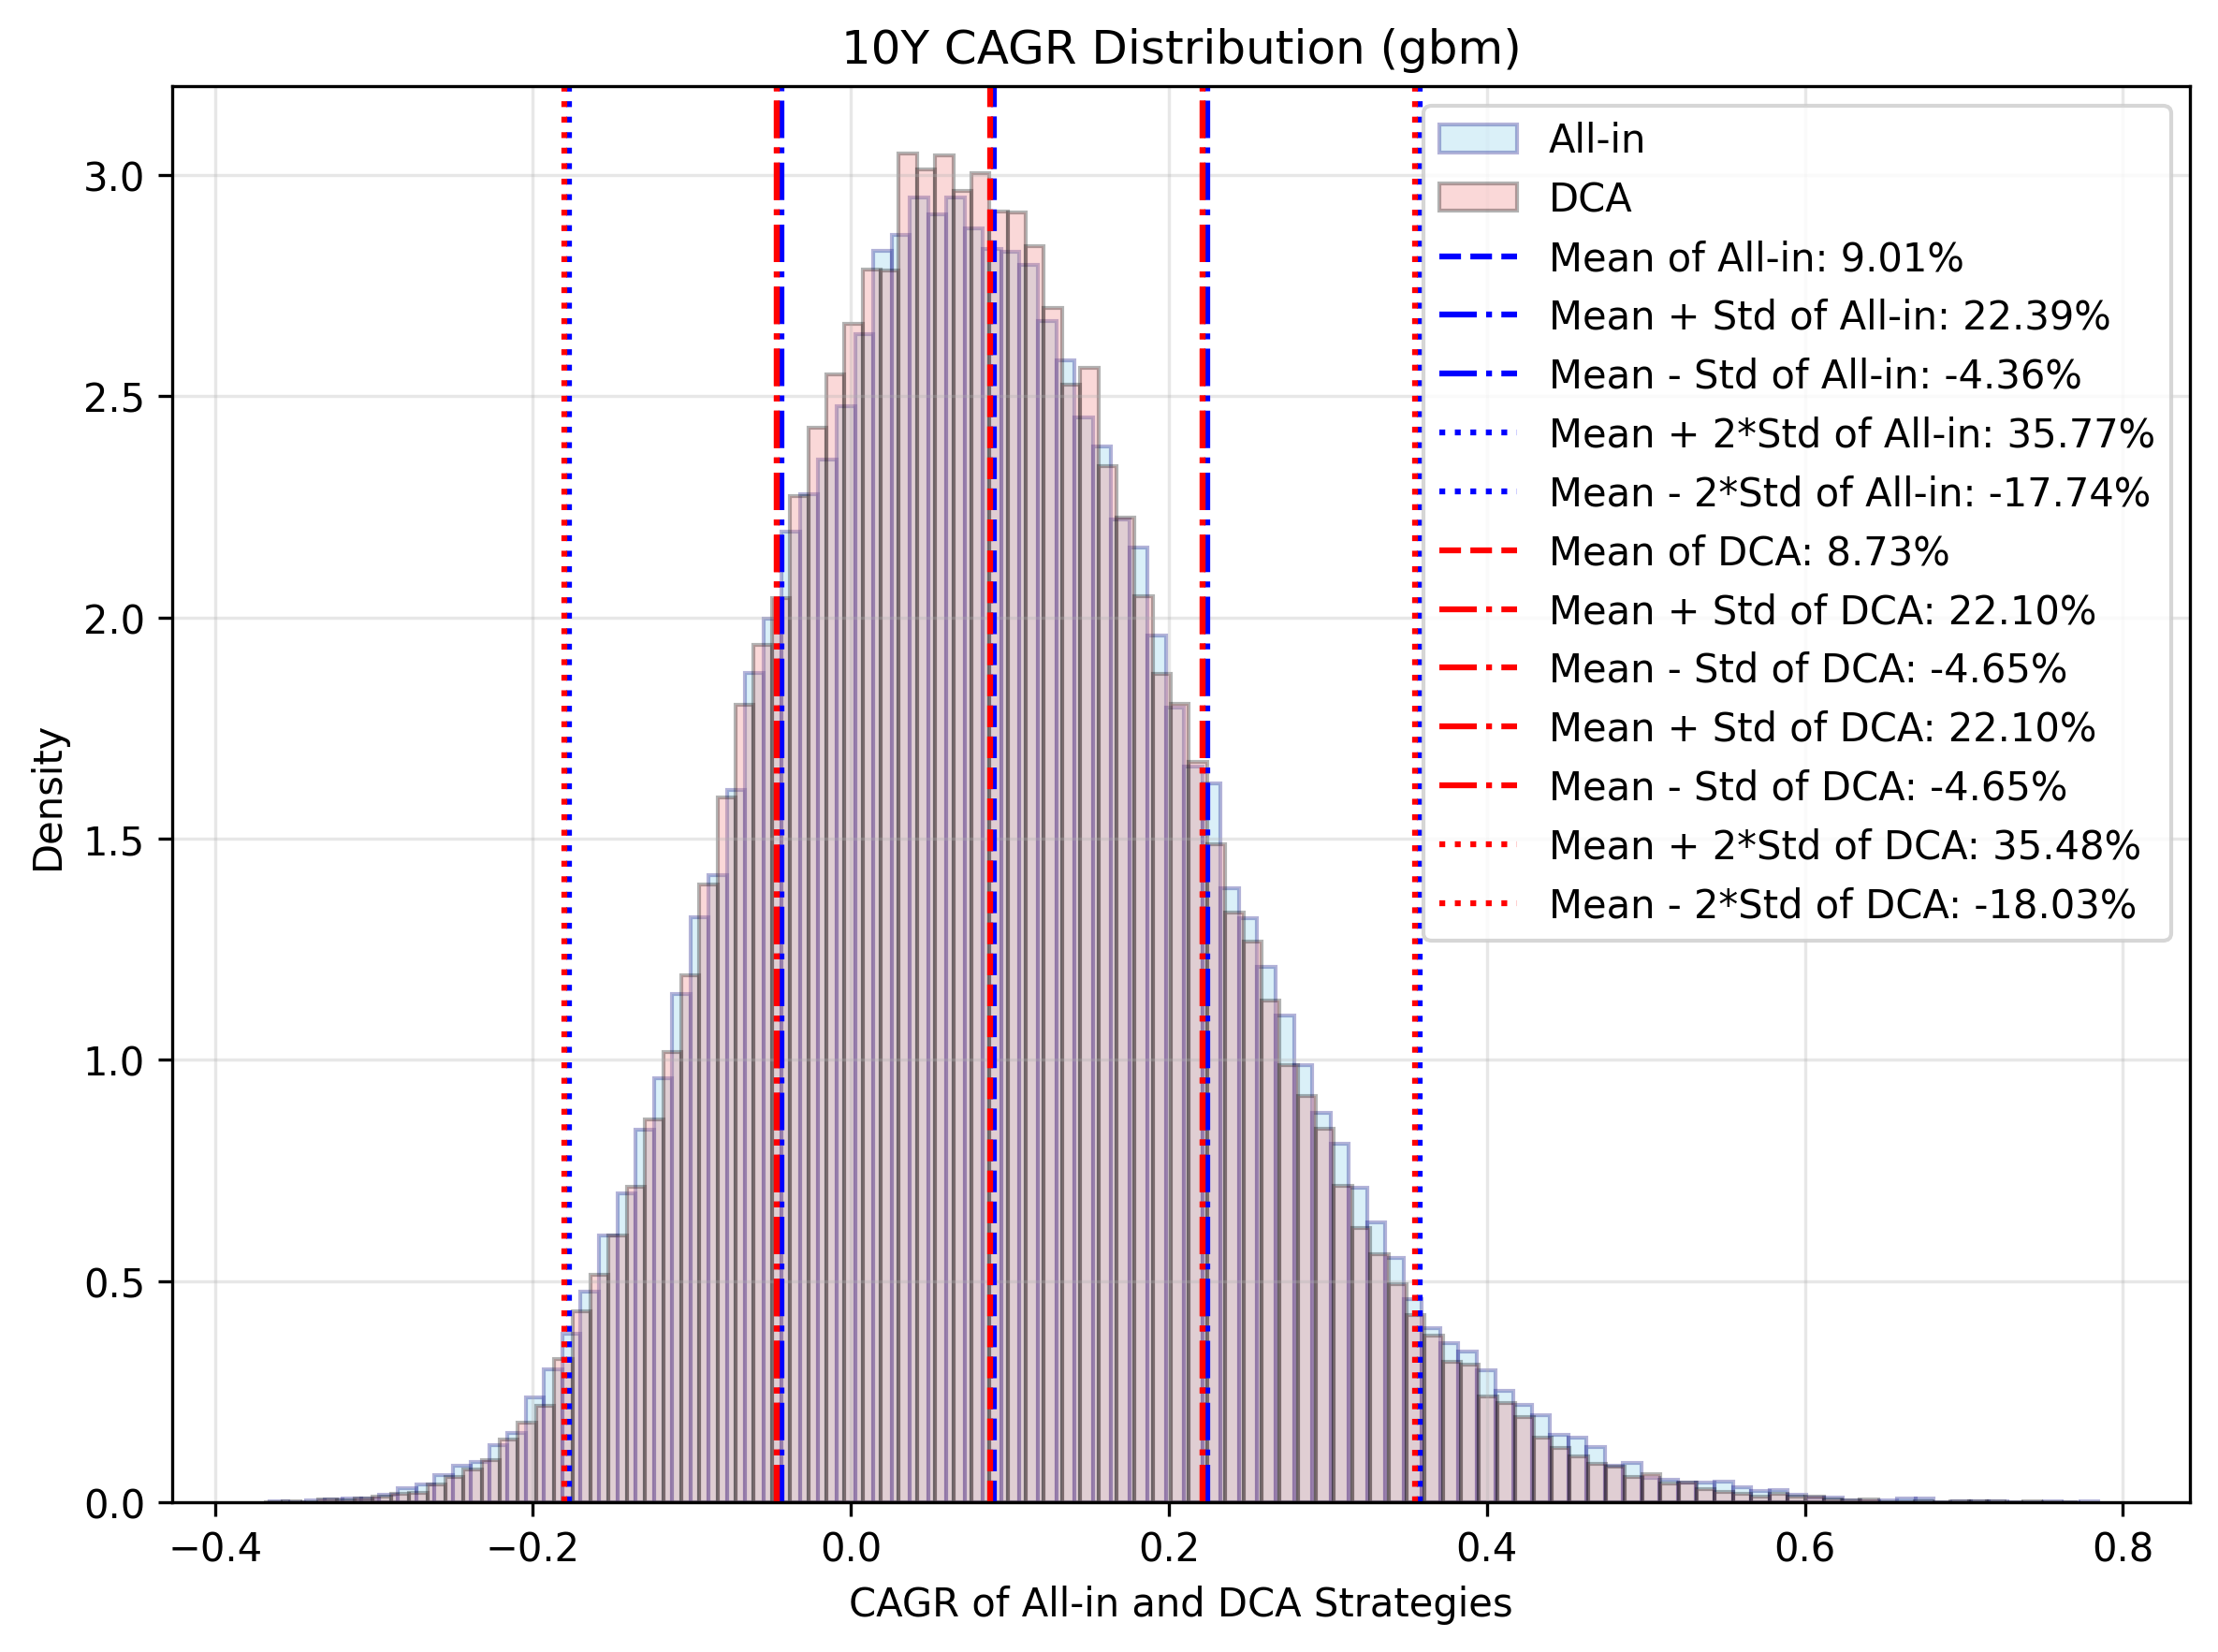
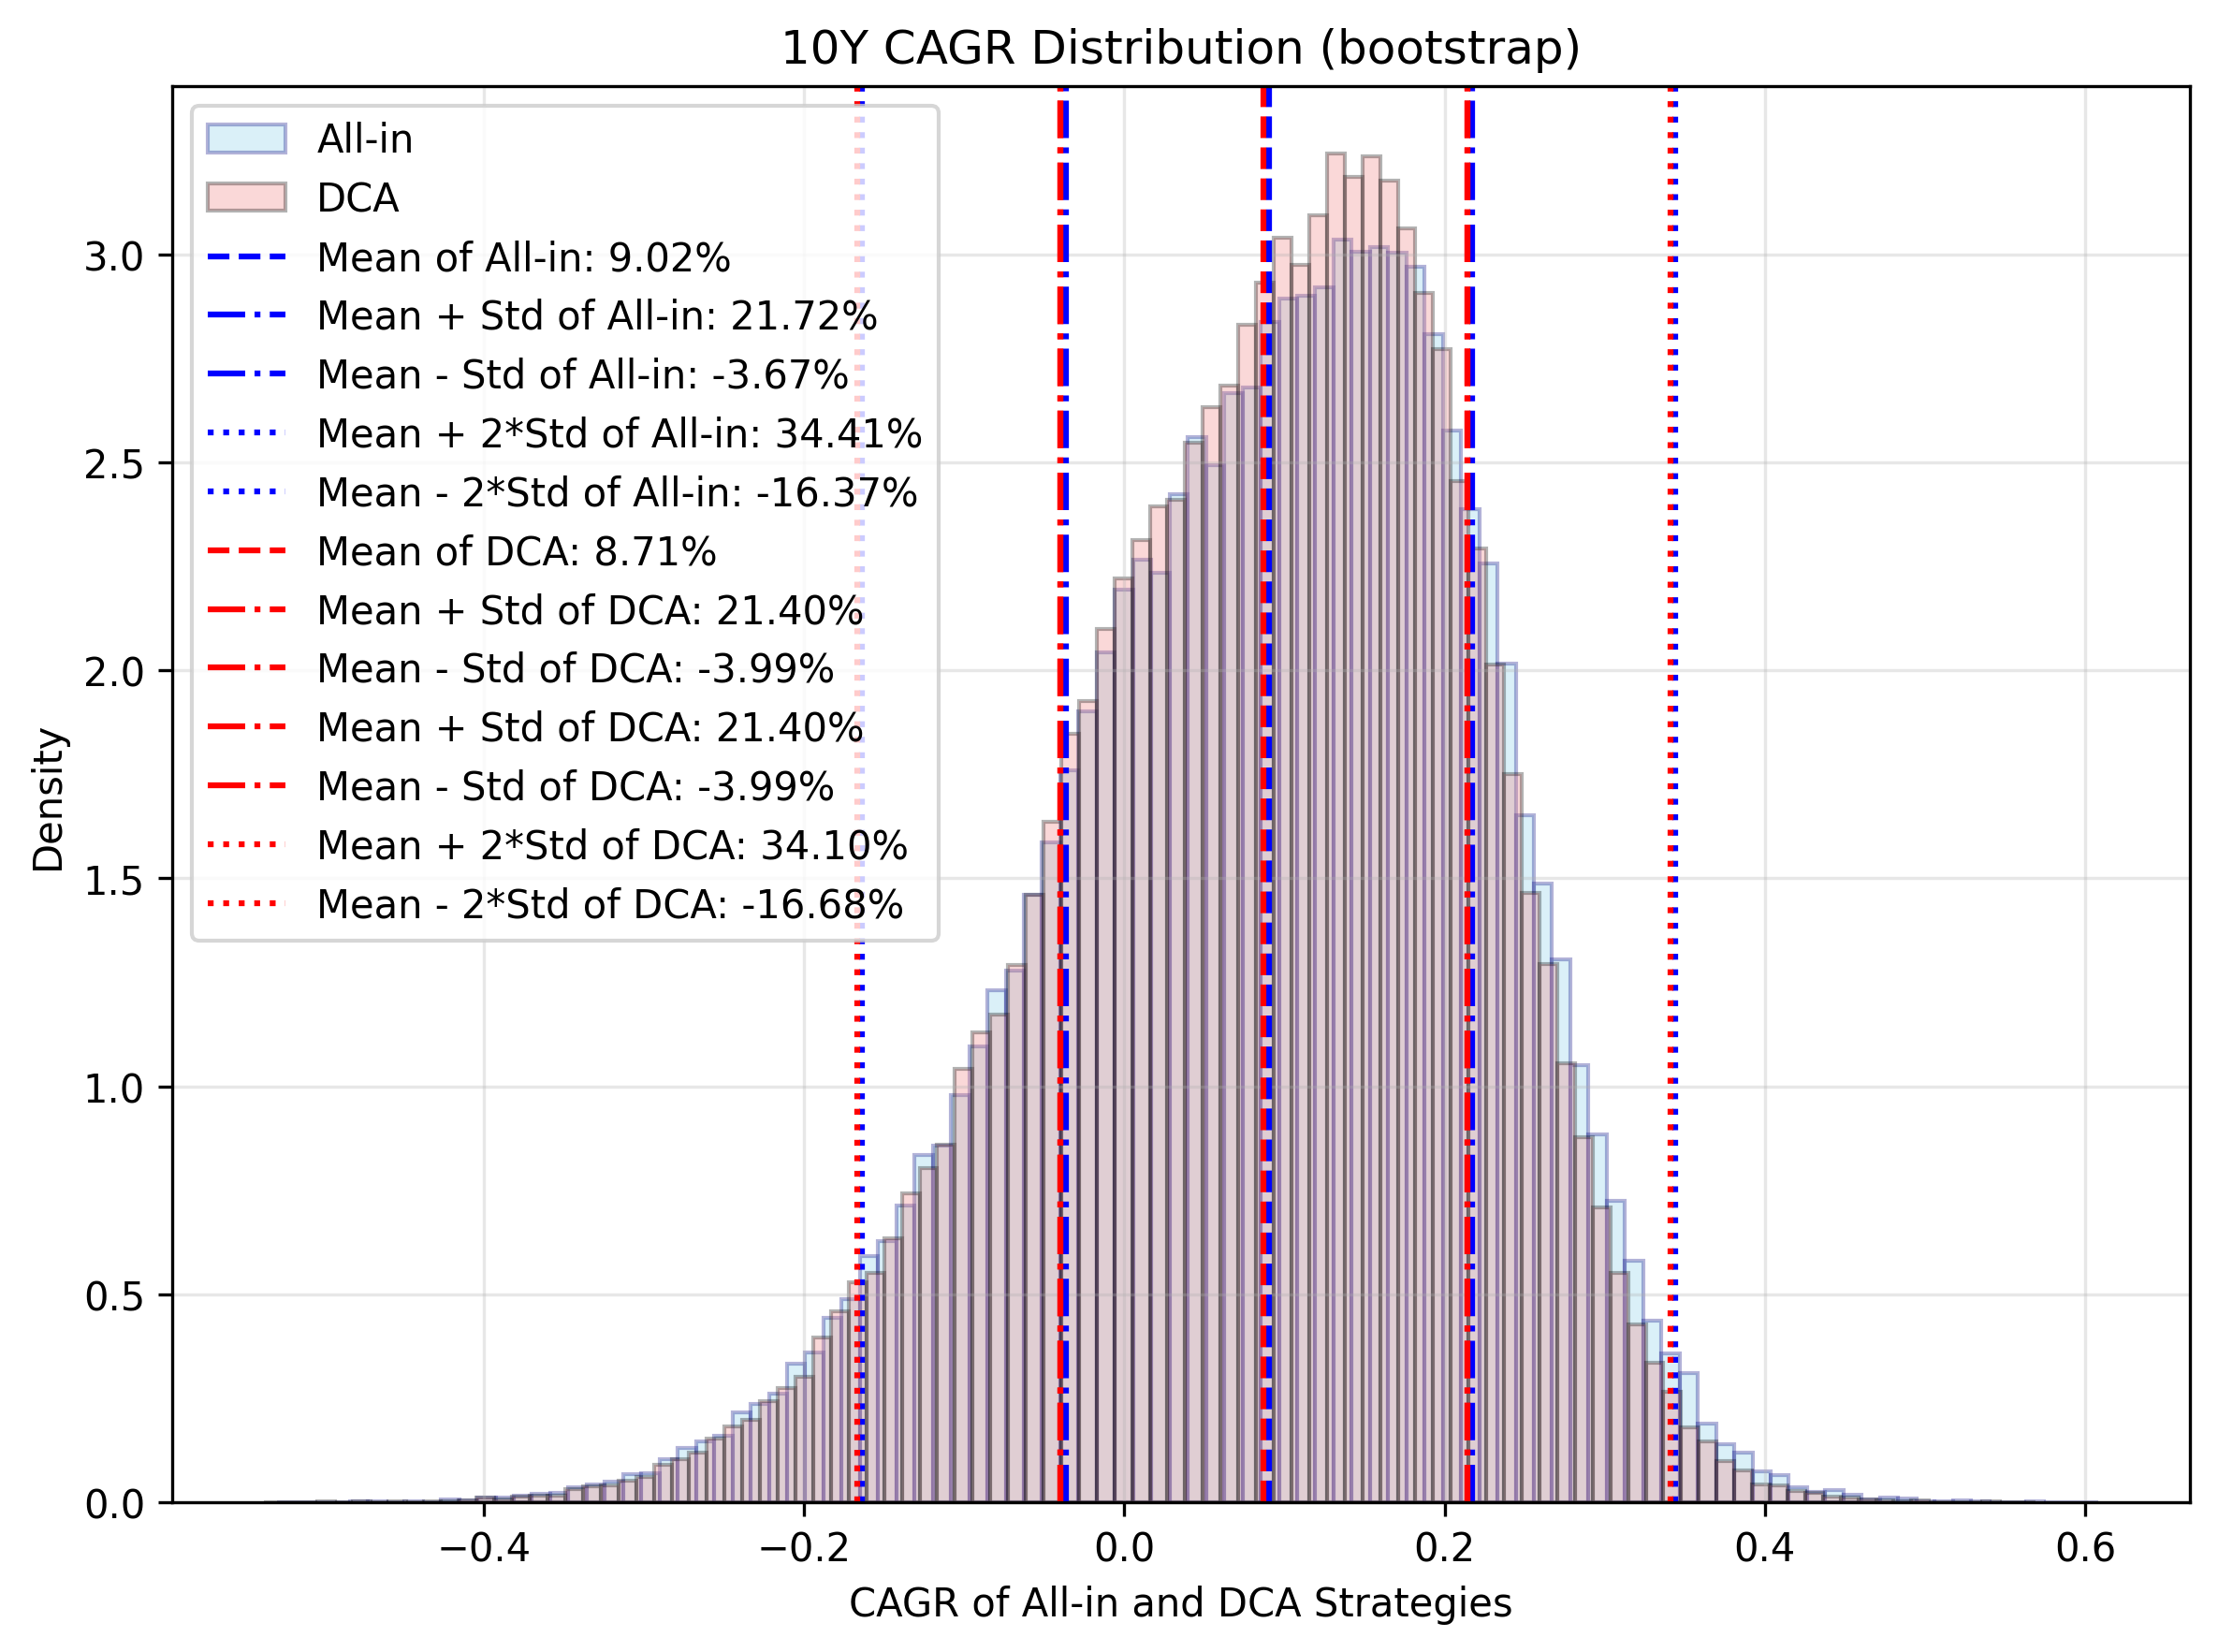



-------------------- Year: 20 --------------------



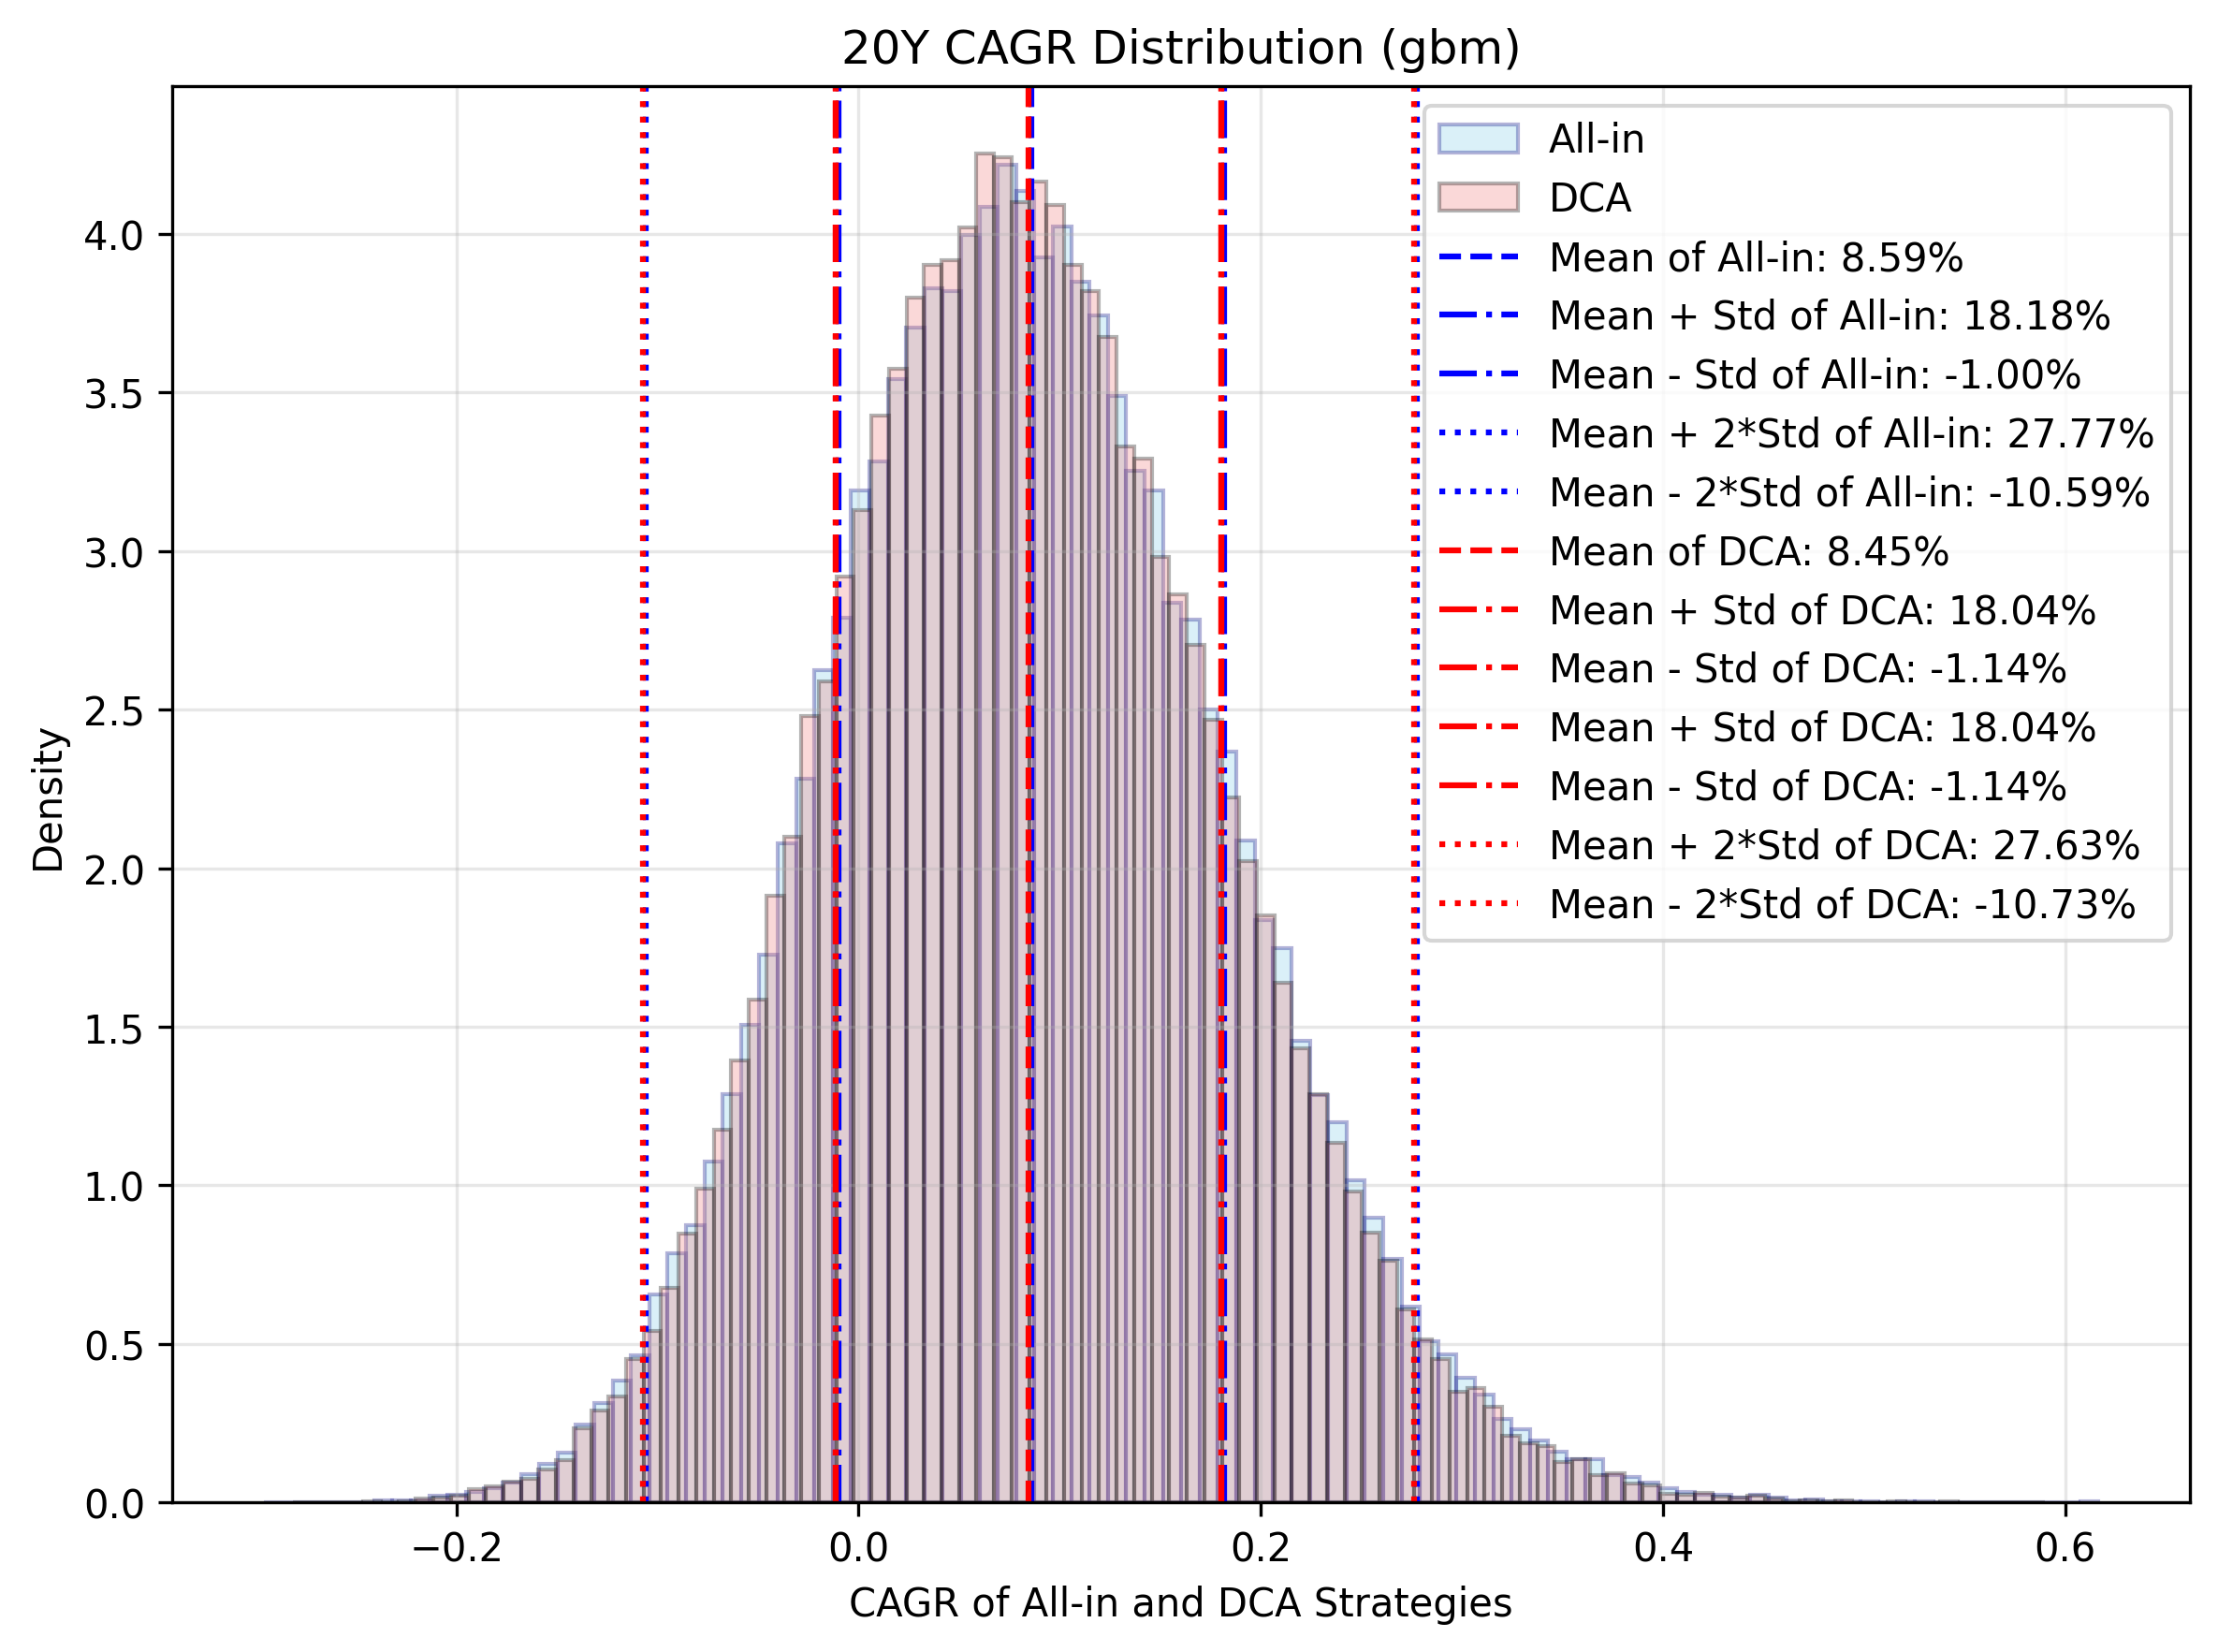
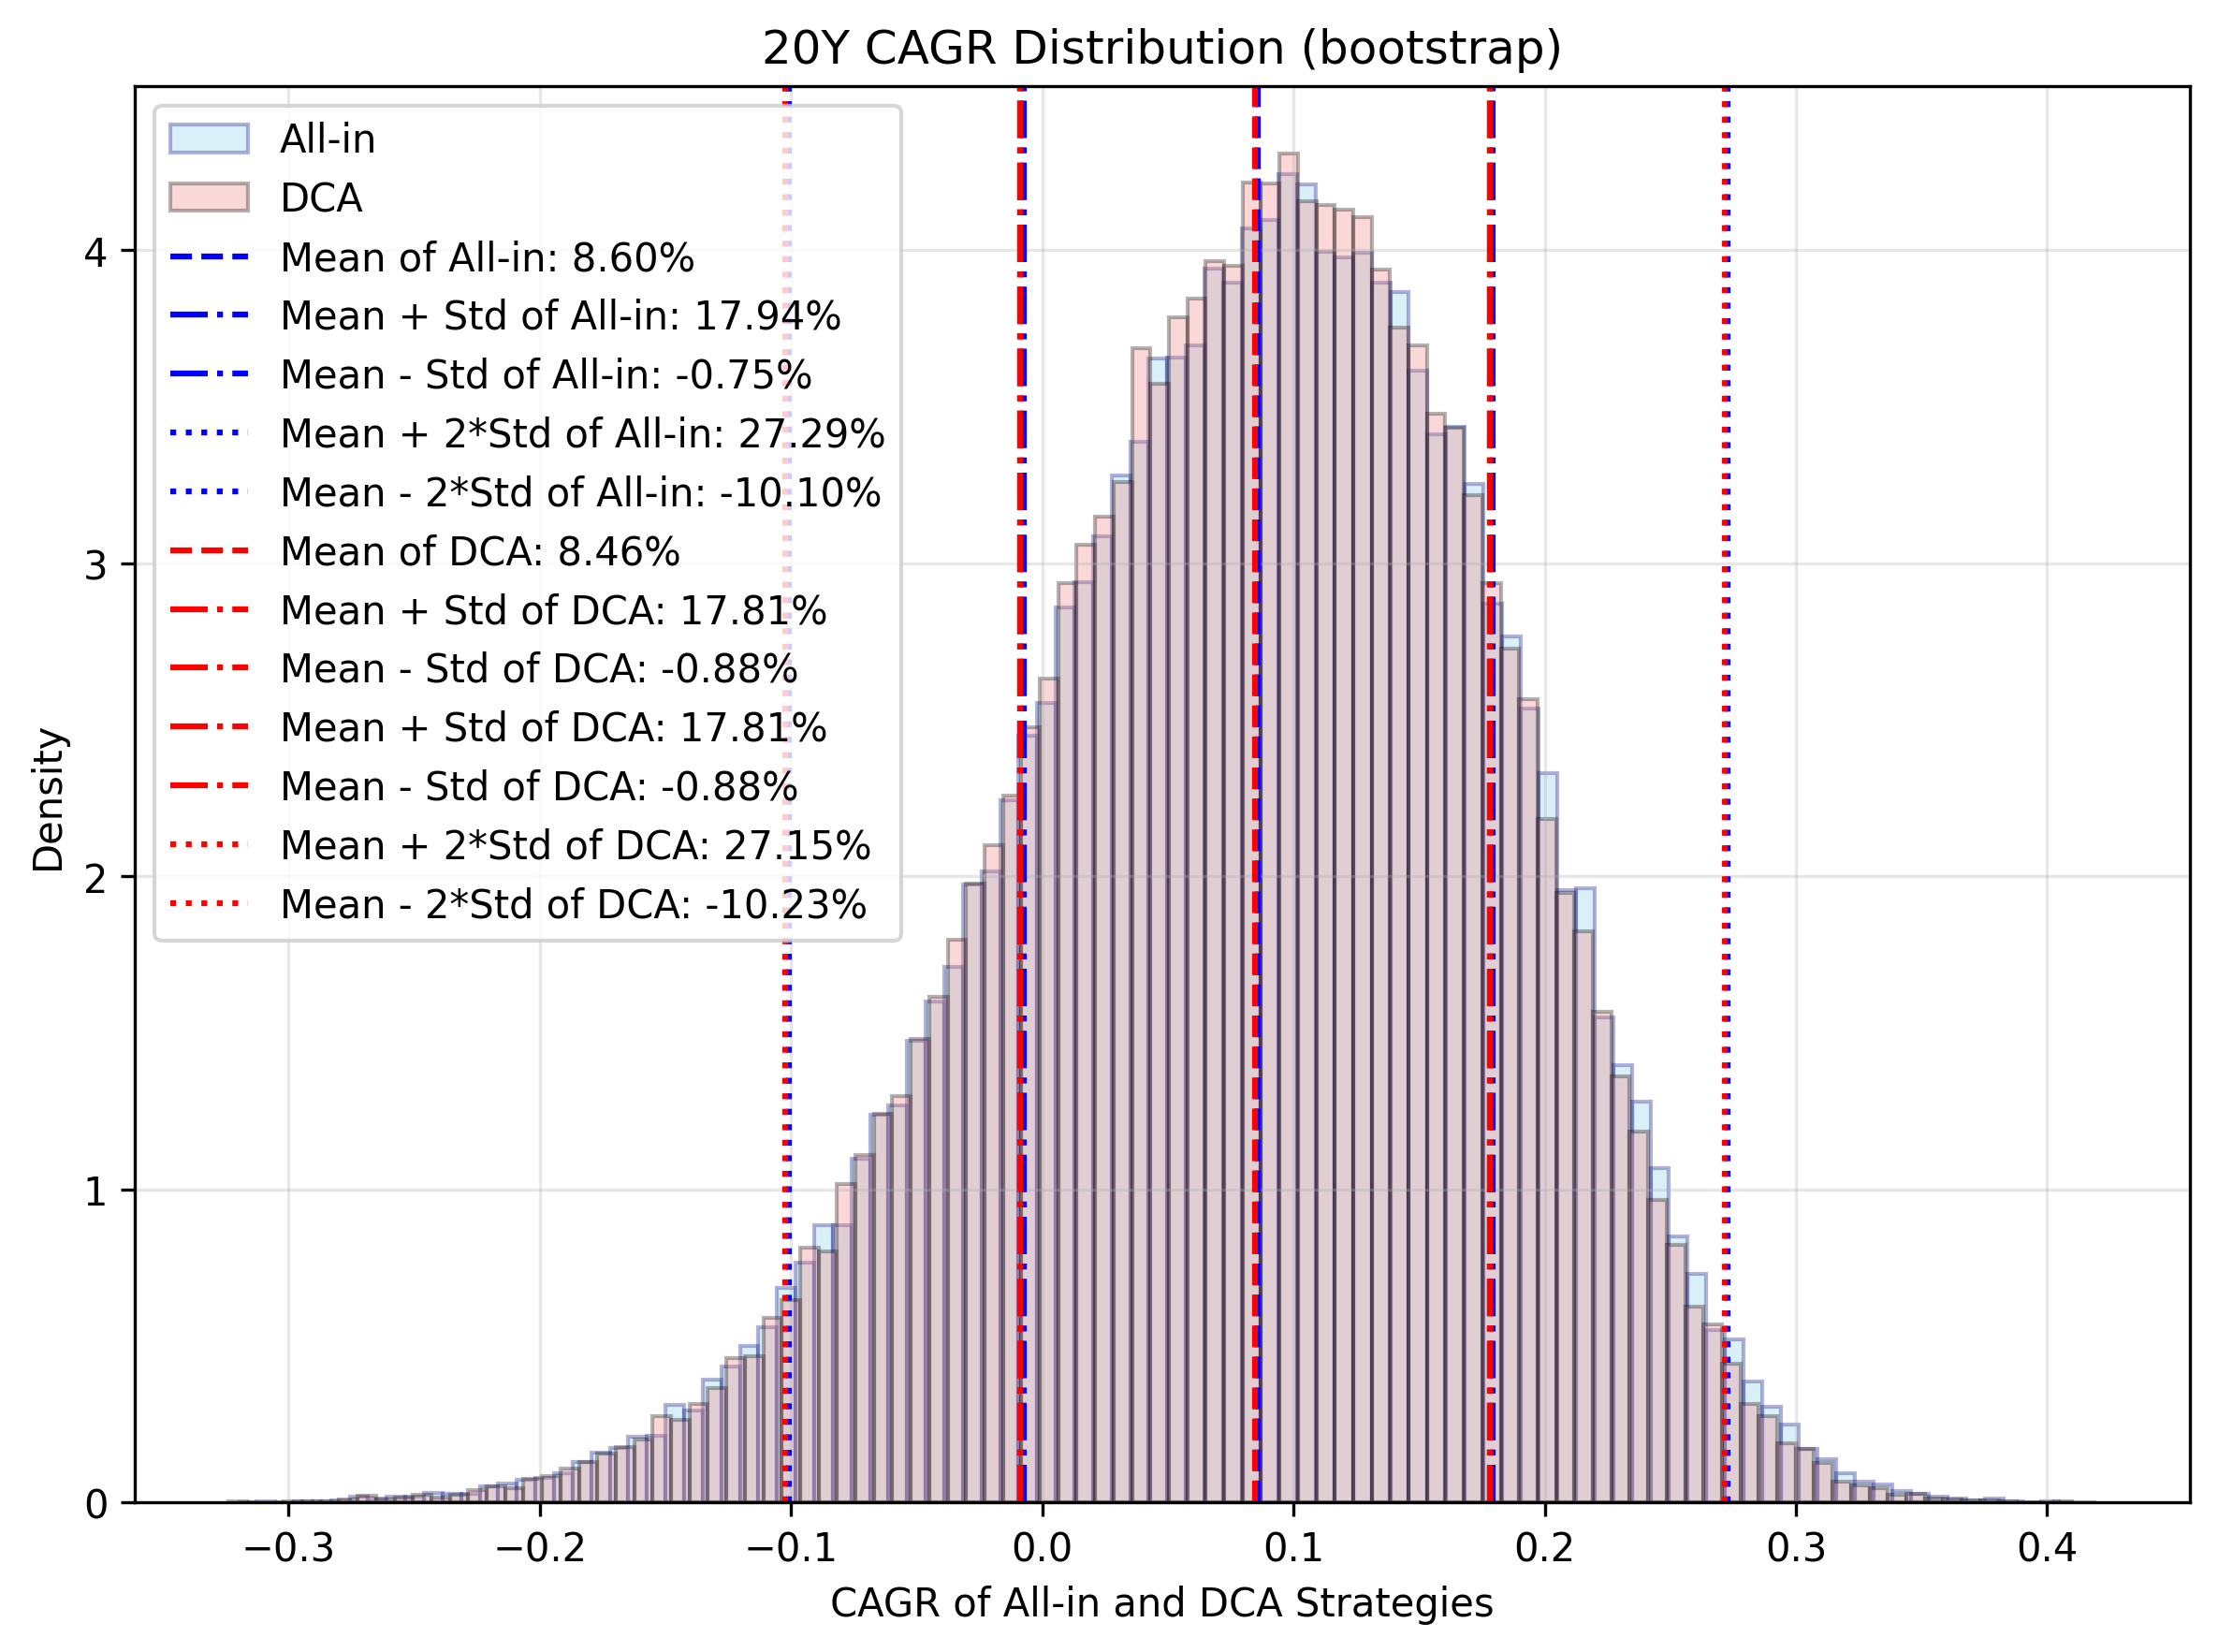



-------------------- Year: 30 --------------------



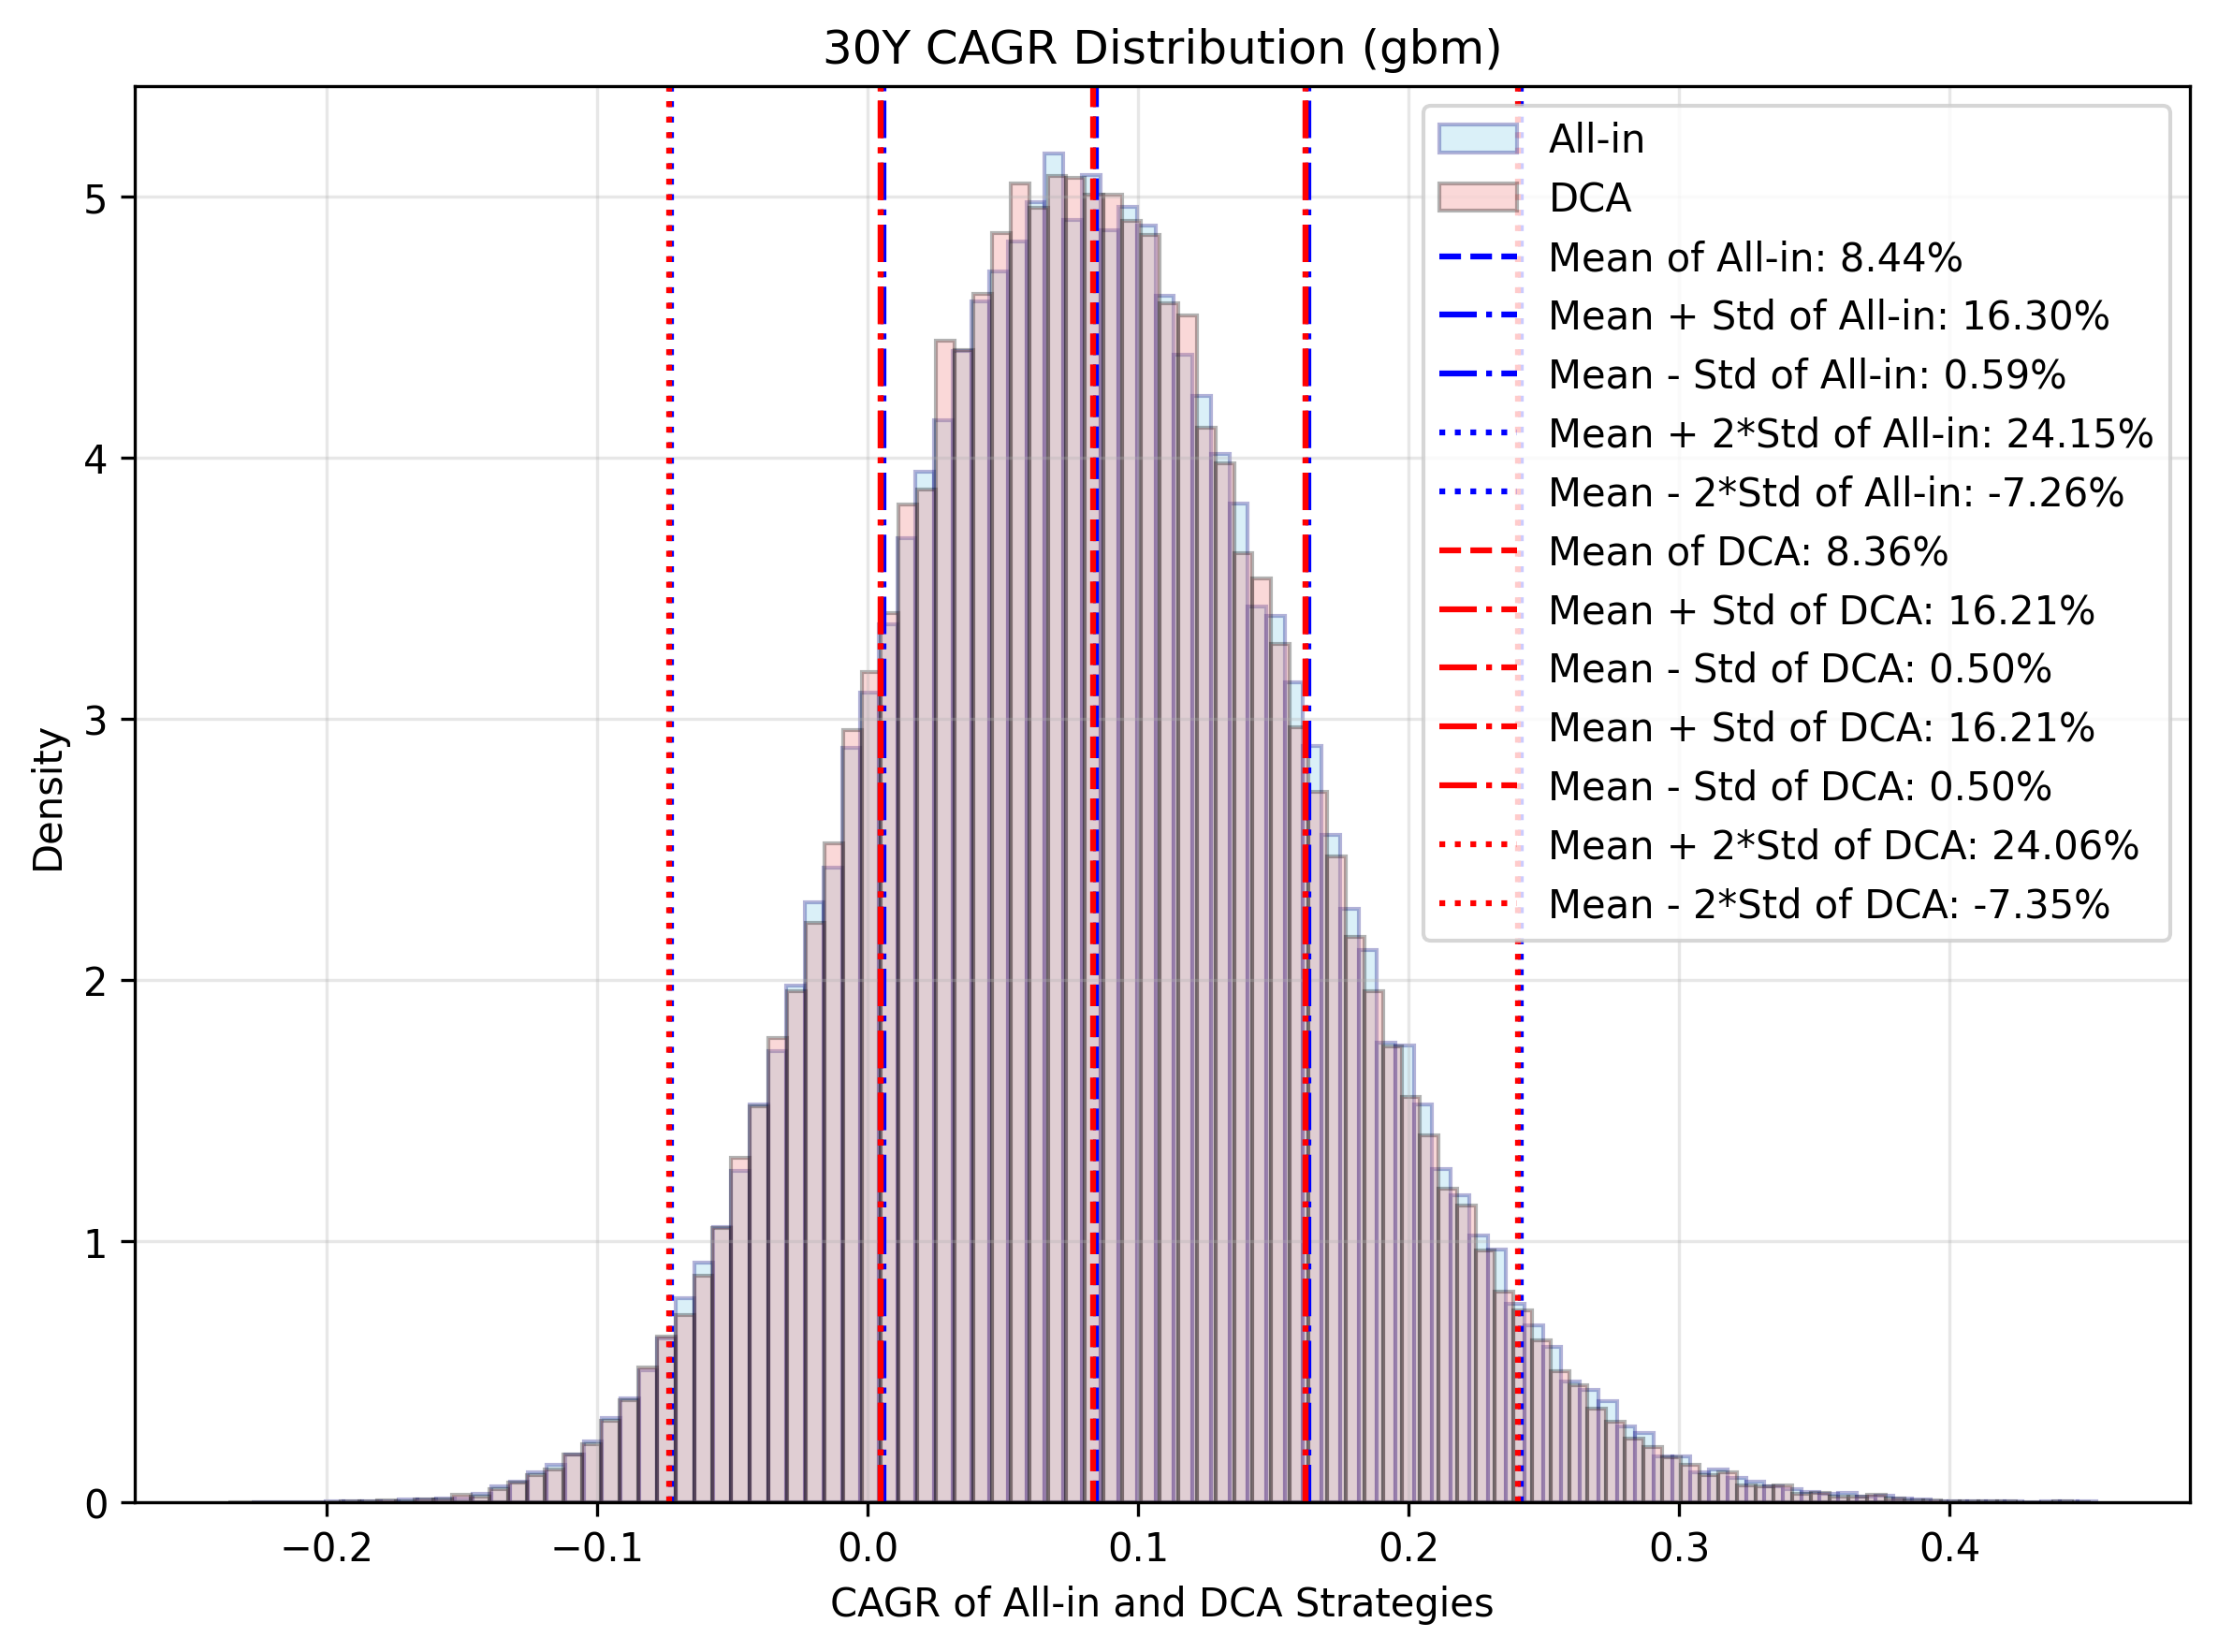
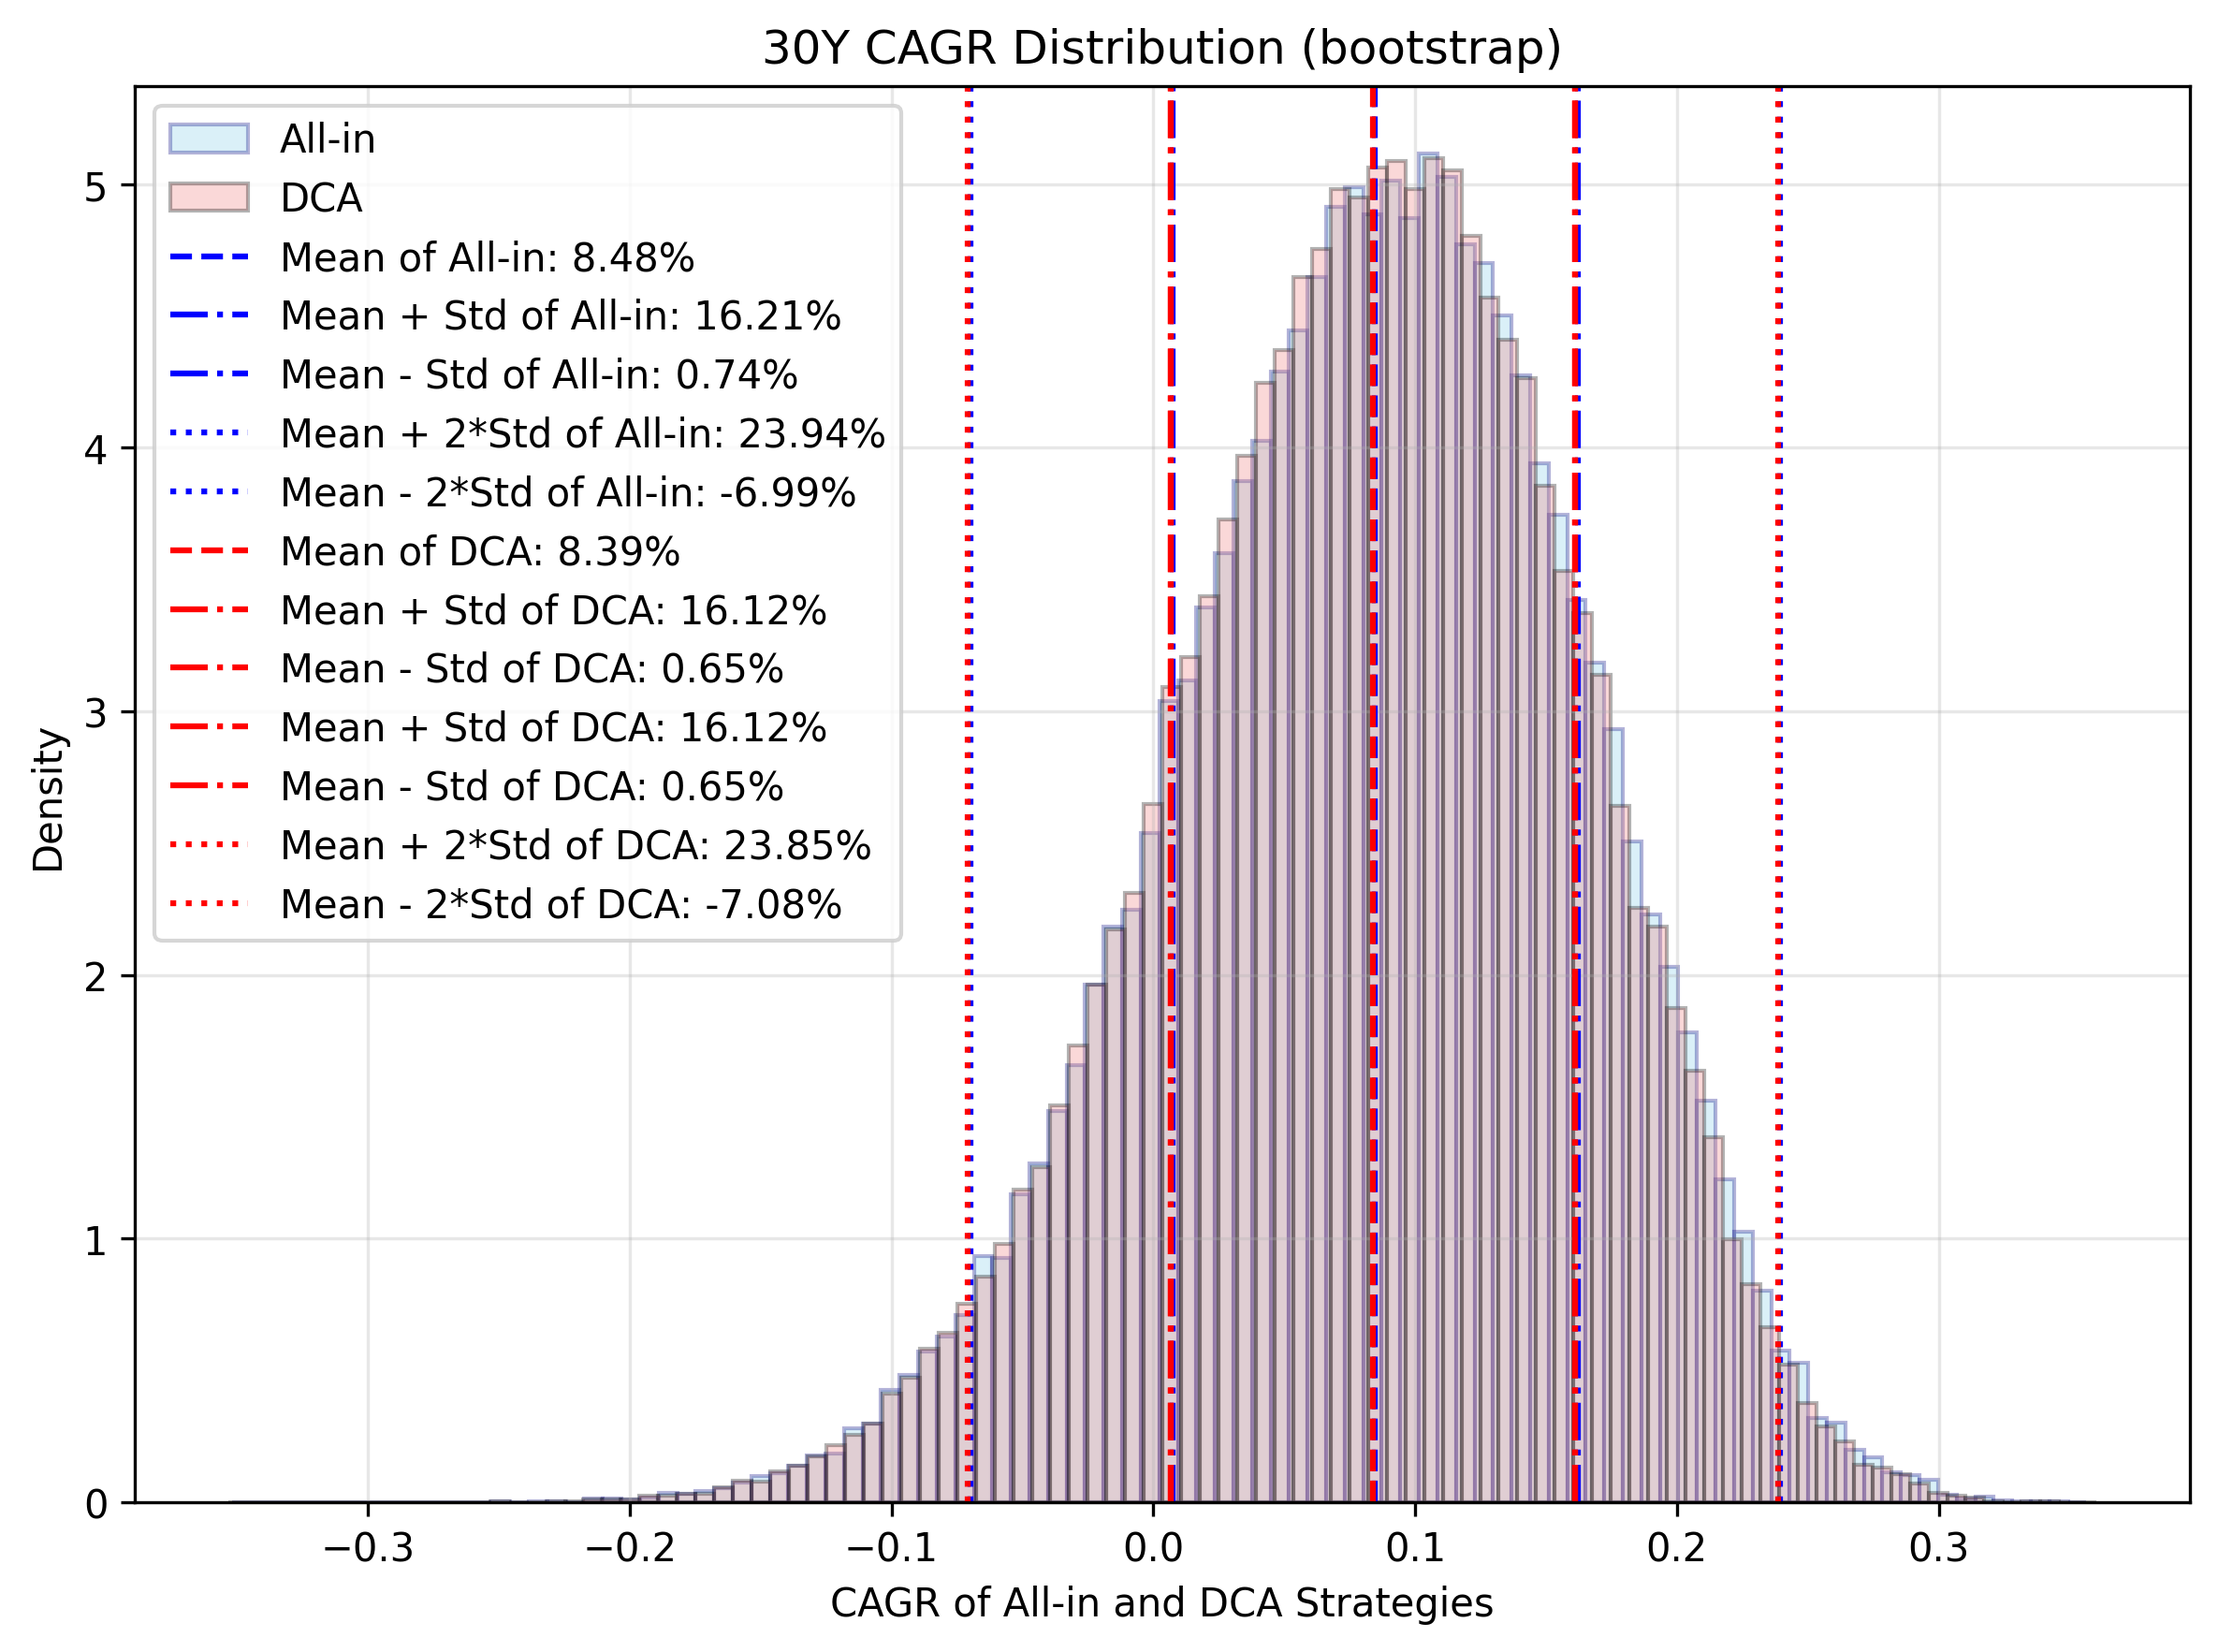

In [32]:
from main import build_output_name

for hy in horizons:
    print("\n")
    print("-"*20 + f" Year: {hy} "+ "-"*20 )

    filename1 = build_output_name(
        analysis="long_horizon_cagr_distribution",
        ticker=MC_PARAMS_BGM["ticker"],
        start=MC_PARAMS_BGM["start"],
        end=MC_PARAMS_BGM["end"],
        ext="png",
        horizon_years=hy,
        method=MC_PARAMS_BGM["method"],
    )

    fig_path1 = get_figure_path(filename1, category="final")  # 或 final，依你實際存放位置

    filename2 = build_output_name(
        analysis="long_horizon_cagr_distribution",
        ticker=MC_PARAMS_BSP["ticker"],
        start=MC_PARAMS_BSP["start"],
        end=MC_PARAMS_BSP["end"],
        ext="png",
        horizon_years=hy,
        method=MC_PARAMS_BSP["method"],
    )

    fig_path2 = get_figure_path(filename2, category="final")  # 或 final，依你實際存放位置


    show_side_by_side([fig_path1, fig_path2])

### 6.5 Statistical Interpretation and Limitations

#### 6.5.1 Model Assumptions

##### GBM
GBM assumes:

$$
r_t \sim \mathcal{N}(\mu, \sigma^2)
$$

This implies:
- i.i.d. returns
- constant drift
- constant volatility

##### Key limitations of GBM
- Underestimates **fat tails**
- Cannot capture **volatility clustering**
- Ignores **regime shifts** such as bull and bear transitions

As a result, GBM may understate true downside risk in real markets.

##### Bootstrap
Bootstrap is more empirical, but it also has limitations:
- It assumes the historical sample is representative of the future
- It does not model structural breaks explicitly
- It preserves the observed distribution only through resampling, not through an economic mechanism

### Bottom line
These models are useful for **decision support**, not for exact forecasting.


### 6.6 Why Simple Models Still Work

Despite strong assumptions, simple models such as GBM and Bootstrap often remain useful in practice.

#### 1. Long-term drift dominates
Over long horizons, equity markets typically exhibit positive drift:

$$
\mathbb{E}[r_t] > 0
$$

That means long-run outcomes are often driven more by **time in the market** than by short-run precision.

#### 2. Strategy ranking can be robust
Even if the model is simplified, the relative ranking between strategies may remain informative:

- investing earlier tends to increase expected return
- smoothing purchases tends to reduce timing risk

#### 3. Interpretability matters
Simple models are easy to explain, debug, and communicate.  
For an investment-decision notebook, this is a practical advantage.

### Takeaway
A simple model can still be valuable when the goal is not perfect prediction, but **clear comparison under uncertainty**.


## 7. Conditional Analysis Near Recent Highs

So far, the Monte Carlo section has simulated the **overall market** without conditioning on any specific state.

In this section, we change the initial condition:

> We only start the simulation from dates when price is very close to a recent high.

This is the simulation counterpart to the historical peak-entry analysis.  
The question is whether DCA becomes more competitive when the market is already in an elevated state and timing risk is higher.


### 7.1 Conditional Monte Carlo Setup and Results

We identify dates where the current price is **within 1% of the historical high over the previous 252 trading days** (roughly one year).  
From those states, we simulate future return paths and compare:

1. **All-in** at the near-high entry point
2. **DCA** spread across 3 months

The simulation is repeated **100,000 times**.

### Results

#### 10-year horizon
- Probability that DCA beats All-in: **0.35557**
- Mean annualized return of All-in: **0.052441135160420815**
- Mean annualized return of DCA: **0.05407896960621969**

#### 20-year horizon
- Probability that DCA beats All-in: **0.35557**
- Mean annualized return of All-in: **0.050772915566139734**
- Mean annualized return of DCA: **0.05171308336671609**

#### 30-year horizon
- Probability that DCA beats All-in: **0.35557**
- Mean annualized return of All-in: **0.050332155**
- Mean annualized return of DCA: *(continue using notebook output if more precision is available)*

### Interpretation
Even in near-high conditions, the difference is subtle:

- DCA can slightly improve the average annualized return in this setup
- But its outright win probability is still well below 50%

This suggests that the advantage of DCA depends strongly on **how performance is defined**:
mean outcome, tail risk, and win probability do not always tell the same story.


In [33]:
from src.analysis.conditional_mc import mc_condition_on_high_state

HORIZONS = [10, 20, 30]

COND_PARAMS = {
    "n_sims": 100_000,
    "window_td": 252,
    "state_mode": "near_high",
    "near_high_threshold": -0.01,
    "pct_threshold": 0.90,
    "breakout_only": True,
    "first_block_days": 252,
    "dca_months": 3,
    "seed": 42
}

price = df.loc[df["is_trade_day"], "Close"].astype(float)

for hy in HORIZONS:
    res = mc_condition_on_high_state(
        price,
        horizon_years=hy,
        **COND_PARAMS
    )

    print(f"\n==== Horizon: {hy} Years ====")
    print("High-state sample count:", res["n_candidates"])
    print("P(DCA beats All-in):", res["p_dca_beats_all_in_terminal"])
    print("E[CAGR All-in]:", res["expected_cagr_all_in"])
    print("E[CAGR DCA]:", res["expected_cagr_dca"])


==== Horizon: 10 Years ====
High-state sample count: 137
P(DCA beats All-in): 0.35557
E[CAGR All-in]: 0.052441149351047
E[CAGR DCA]: 0.05407898437079377

==== Horizon: 20 Years ====
High-state sample count: 137
P(DCA beats All-in): 0.35557
E[CAGR All-in]: 0.0507729326718872
E[CAGR DCA]: 0.05171310077520866

==== Horizon: 30 Years ====
High-state sample count: 137
P(DCA beats All-in): 0.35557
E[CAGR All-in]: 0.05033217260023972
E[CAGR DCA]: 0.050985337698222194


## 8. Conclusion

This project compares All-in and DCA using:

- historical backtesting
- peak-entry analysis
- long-horizon Monte Carlo simulation
- conditional simulation near recent highs

### Overall takeaways

1. **All-in generally provides the higher expected return**, especially in upward-trending markets.
2. **DCA reduces downside risk**, particularly when the entry point is unfavorable.
3. Relative performance depends strongly on **market state at entry**.
4. Therefore, the choice between All-in and DCA should be viewed as a **risk-management decision**, not just a return-maximization decision.

### Practical implication
- If the investor has strong conviction and a long horizon, **All-in** is usually favored on expected return.
- If the investor is worried about buying at a local peak or cares more about downside protection, **DCA** becomes more attractive.


## 9. Practical Decision Framework

- If investment horizon is long and risk tolerance is high → **All-in** 
- If market is near peak or timing is uncertain → **DCA** 

### Suggested Rule 
- Bull market / strong trend → All-in 
- Near historical highs → DCA - High volatility regime → DCA

## 10. Limitations

- Single asset only: **0050.TW**
- Sample period is dominated by a long post-2009 bull regime
- No transaction cost, tax, or slippage
- Simulation assumptions remain simplified, especially under GBM
- Results are sensitive to the exact DCA schedule and horizon definition

These results should therefore be interpreted as **decision support**, not investment advice.


## 11. Future Work

Possible extensions include:

- regime-switching models
- multi-asset comparison
- macro-conditioned analysis
- richer tail-risk metrics
- transaction-cost and tax-aware implementation
- sensitivity analysis for different DCA schedules

These extensions would make the framework more realistic and more useful for portfolio construction.


## Appendix: Why This Matters

This study highlights a simple but important point:

> Investment performance is not only about **which strategy** is chosen,  
> but also about **when** that strategy is applied.

Understanding timing risk matters because the same strategy can look very different under:

- a normal entry state
- a local-peak entry state
- a long compounding horizon
- a short and fragile horizon

That is why All-in vs. DCA should be evaluated as a **conditional decision problem**, not a one-line rule.
